In [ ]:
import os
#os.chdir("//share/data/AFTLab/SC/")

from google.colab import drive
drive.mount('/content/drive')
#os.chdir("drive/MyDrive/DehanCui/data")

root_dir = "/content/drive/My Drive/"
project_folder = "Asset pricing x supply chain project/Main_Code"
os.chdir(root_dir + project_folder)

import torch
from torch_geometric.data import Data, DataLoader
from torch_geometric.nn import GCNConv, SAGEConv, GATConv, TransformerConv
from torch.optim import Adam
import torch.nn.functional as F
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from tqdm import tqdm  # Progress bar
import matplotlib.pyplot as plt
import pickle as pkl

# Plot heatmap of Sharpe ratios

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

Mounted at /content/drive


#NN Benchmark: Multi-Layer Perceptron

In [ ]:
### MLP ###
import numpy as np
import pandas as pd
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam


# -----------------------------
# Dataset
# -----------------------------
class PanelDataset(Dataset):
    def __init__(self, X: np.ndarray, y: np.ndarray, node_idx: np.ndarray, yyyymm: np.ndarray):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
        self.node_idx = torch.tensor(node_idx, dtype=torch.long)
        self.yyyymm = yyyymm

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, i):
        return self.X[i], self.y[i], self.node_idx[i], self.yyyymm[i]


# -----------------------------
# MLP Model (configurable hidden layers)
# -----------------------------
class MLPModel(nn.Module):
    """
    Returns (predictions, embeddings) where embeddings has dimension embedding_dim,
    similar to your GNN returning (out(x), x_embedding).
    """
    def __init__(
        self,
        input_dim: int,
        embedding_dim: int = 16,
        num_hidden_layers: int = 2,
        hidden_dim: int = 64,
        dropout: float = 0.3,
        use_batchnorm: bool = True,
    ):
        super().__init__()

        layers = []
        in_dim = input_dim

        # BN on raw features
        self.bn_in = nn.BatchNorm1d(input_dim) if use_batchnorm else None

        # hidden stack
        for _ in range(num_hidden_layers):
            layers.append(nn.Linear(in_dim, hidden_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            in_dim = hidden_dim

        # embedding head (so embeddings always have size embedding_dim)
        self.to_embedding = nn.Linear(in_dim, embedding_dim)

        # output head
        self.out = nn.Linear(embedding_dim, 1)

        self.hidden = nn.Sequential(*layers)

    def forward(self, x):
        if self.bn_in is not None:
            x = self.bn_in(x)

        x = self.hidden(x)              # (B, hidden_dim) or (B, input_dim) if no hidden layers
        emb = F.relu(self.to_embedding(x))  # (B, embedding_dim)
        pred = self.out(emb)            # (B, 1)
        return pred, emb


# -----------------------------
# Training function
# -----------------------------
def train_mlp_panel(
    df: pd.DataFrame,
    feature_cols: list,
    split_yyyymm,
    target_col: str = "mthret",
    entity_col: str = "FACTSET_ENTITY_ID",
    month_col: str = "yyyymm",
    embedding_dim: int = 16,
    num_hidden_layers: int = 2,
    hidden_dim: int = 64,
    epochs: int = 80,
    batch_size: int = 1024,
    lr: float = 1e-3,
    weight_decay: float = 1e-4,
    dropout: float = 0.3,
    use_batchnorm: bool = True,
    device: str = None,
    global_node_map: dict = None,
    save_csv_prefix: str = None,
):
    """
    MLP version of your GNN train_model:
    - Splits by yyyymm threshold
    - Trains on (X=feature_cols, y=target_col)
    - Returns prediction + embedding panels matching your GNN output format.

    Outputs:
      model, train_losses, test_losses,
      train_corrections_df, train_embeddings_df,
      test_corrections_df, test_embeddings_df
    """
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    # --- clean & keep only needed cols
    needed_cols = [month_col, entity_col, target_col] + list(feature_cols)
    work = df[needed_cols].copy()

    # ensure month comparable

    work[month_col] = work[month_col].astype(str)

    # drop missing in X/y
    work = work.dropna(subset=[target_col] + list(feature_cols) + [month_col, entity_col]).copy()

    # --- node mapping
    if global_node_map is None:
        unique_entities = pd.Index(work[entity_col].unique())
        global_node_map = {ent: i for i, ent in enumerate(unique_entities)}
    node_gvkey_df = pd.DataFrame(
        [(ent, idx) for ent, idx in global_node_map.items()],
        columns=[entity_col, "node_idx"]
    )

    work["node_idx"] = work[entity_col].map(global_node_map).astype(int)

    # --- split
    split_yyyymm = str(split_yyyymm)
    train_mask = work[month_col].astype(str) <= split_yyyymm
    test_mask  = work[month_col].astype(str) > split_yyyymm

    train_df = work.loc[train_mask].copy()
    test_df  = work.loc[test_mask].copy()

    if len(train_df) == 0 or len(test_df) == 0:
        raise ValueError("Invalid split_yyyymm: need observations on both sides of the split.")

    # --- build X/y
    X_train = train_df[feature_cols].to_numpy(dtype=np.float32)
    y_train = train_df[target_col].to_numpy(dtype=np.float32)

    X_test  = test_df[feature_cols].to_numpy(dtype=np.float32)
    y_test  = test_df[target_col].to_numpy(dtype=np.float32)

    # --- standardize using train stats only
    #mu = X_train.mean(axis=0)
    #sd = X_train.std(axis=0)
    #sd[sd == 0] = 1.0

    #X_train = (X_train - mu) / sd
    #X_test  = (X_test  - mu) / sd

    # --- datasets/loaders
    train_ds = PanelDataset(
        X_train, y_train,
        node_idx=train_df["node_idx"].to_numpy(),
        yyyymm=train_df[month_col].to_numpy()
    )
    test_ds = PanelDataset(
        X_test, y_test,
        node_idx=test_df["node_idx"].to_numpy(),
        yyyymm=test_df[month_col].to_numpy()
    )

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=False)
    test_loader  = DataLoader(test_ds, batch_size=batch_size, shuffle=False, drop_last=False)

    # --- model/opt
    model = MLPModel(
        input_dim=len(feature_cols),
        embedding_dim=embedding_dim,
        num_hidden_layers=num_hidden_layers,
        hidden_dim=hidden_dim,
        dropout=dropout,
        use_batchnorm=use_batchnorm,
    ).to(device)

    optimizer = Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.MSELoss()

    train_losses, test_losses = [], []

    # --- train loop
    for epoch in tqdm(range(epochs), desc="MLP Training Progress"):
        model.train()
        total_train_loss = 0.0

        for Xb, yb, _, _ in train_loader:
            Xb = Xb.to(device)
            yb = yb.to(device).unsqueeze(1)  # (B,1)

            optimizer.zero_grad()
            pred, _ = model(Xb)
            loss = criterion(pred, yb)
            loss.backward()
            optimizer.step()

            total_train_loss += loss.item()

        model.eval()
        total_test_loss = 0.0
        with torch.no_grad():
            for Xb, yb, _, _ in test_loader:
                Xb = Xb.to(device)
                yb = yb.to(device).unsqueeze(1)
                pred, _ = model(Xb)
                total_test_loss += criterion(pred, yb).item()

        train_losses.append(total_train_loss / max(1, len(train_loader)))
        test_losses.append(total_test_loss / max(1, len(test_loader)))

    # --- inference to build output panels
    def build_output_panels(df_part: pd.DataFrame, X_part: np.ndarray) -> tuple[pd.DataFrame, pd.DataFrame]:
        model.eval()

        # batch inference over rows
        ds = PanelDataset(
            X_part,
            df_part[target_col].to_numpy(dtype=np.float32),
            node_idx=df_part["node_idx"].to_numpy(),
            yyyymm=df_part[month_col].to_numpy()
        )
        loader = DataLoader(ds, batch_size=batch_size, shuffle=False, drop_last=False)

        preds_list = []
        embs_list = []
        node_idx_list = []
        yyyymm_list = []

        with torch.no_grad():
            for Xb, _, node_idx_b, yyyymm_b in loader:
                Xb = Xb.to(device)
                pred_b, emb_b = model(Xb)

                preds_list.append(pred_b.squeeze(1).cpu().numpy())
                embs_list.append(emb_b.cpu().numpy())
                node_idx_list.append(node_idx_b.cpu().numpy())
                yyyymm_list.append(np.array(yyyymm_b, dtype=object))

        preds = np.concatenate(preds_list, axis=0)
        embs = np.concatenate(embs_list, axis=0)
        node_idx_arr = np.concatenate(node_idx_list, axis=0)
        yyyymm_arr = np.concatenate(yyyymm_list, axis=0)

        base = pd.DataFrame({
            "node_idx": node_idx_arr,
            "yyyymm": yyyymm_arr.astype(str),
        })

        # predictions panel
        pred_df = base.copy()
        pred_df["predicted_correction"] = preds

        # embeddings panel
        emb_df = base.copy()
        for i in range(embedding_dim):
            emb_df[f"embedding_dim_{i}"] = embs[:, i]

        # merge in FACTSET_ENTITY_ID
        pred_df = pred_df.merge(node_gvkey_df, on="node_idx", how="left")
        emb_df  = emb_df.merge(node_gvkey_df, on="node_idx", how="left")

        return pred_df, emb_df

    train_corrections_df, train_embeddings_df = build_output_panels(train_df, X_train)
    test_corrections_df, test_embeddings_df = build_output_panels(test_df, X_test)

    # drop node_idx column from all dataframes
    train_corrections_df.drop("node_idx", axis=1, inplace=True)
    train_embeddings_df.drop("node_idx", axis=1, inplace=True)
    test_corrections_df.drop("node_idx", axis=1, inplace=True)
    test_embeddings_df.drop("node_idx", axis=1, inplace=True)

    train_corrections_df.to_csv(f"../data/factset_tests/MLP/40_dim_MLP_{num_hidden_layers}_hidden_layers_train_corrections_dropout{dropout}_lr_{lr}_L2_{weight_decay}_batch_{batch_size}.csv", index=False)
    train_embeddings_df.to_csv(f"../data/factset_tests/MLP/40_dim_MLP_{num_hidden_layers}_hidden_layers_train_embeddings_dropout{dropout}_lr_{lr}_L2_{weight_decay}_batch_{batch_size}.csv", index=False)
    test_corrections_df.to_csv(f"../data/factset_tests/MLP/40_dim_MLP_{num_hidden_layers}_hidden_layers_test_corrections_dropout{dropout}_lr_{lr}_L2_{weight_decay}_batch_{batch_size}.csv", index=False)
    test_embeddings_df.to_csv(f"../data/factset_tests/MLP/40_dim_MLP_{num_hidden_layers}_hidden_layers_test_embeddings_dropout{dropout}_lr_{lr}_L2_{weight_decay}_batch_{batch_size}.csv", index=False)

    return (
        model,
        train_losses,
        test_losses,
        train_corrections_df,
        train_embeddings_df,
        test_corrections_df,
        test_embeddings_df,
    )

In [ ]:
# drop duplicates from df
df = df.drop_duplicates()

In [ ]:
model, train_losses, test_losses, train_pred, train_emb, test_pred, test_emb = train_mlp_panel(
    df=df,
    feature_cols=feature_cols,
    split_yyyymm="201612",
    embedding_dim=40,
    num_hidden_layers=2,
    hidden_dim=40, #128,
    epochs=80,
    batch_size=32, dropout=0, lr=.001, weight_decay=1e-4)

MLP Training Progress: 100%|██████████| 80/80 [08:30<00:00,  6.38s/it]


In [ ]:
model, train_losses, test_losses, train_pred, train_emb, test_pred, test_emb = train_mlp_panel(
    df=df,
    feature_cols=feature_cols,
    split_yyyymm="201612",
    embedding_dim=40,
    num_hidden_layers=3,
    hidden_dim=40, #128,
    epochs=80,
    batch_size=32, dropout=0, lr=.001, weight_decay=1e-4)

MLP Training Progress: 100%|██████████| 80/80 [04:46<00:00,  3.58s/it]


In [ ]:
# plot traain and test losses
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Test Loss')
plt.legend()
plt.show()

# Cross-Sectional R2 for GNN

In [ ]:
### Monthly R2 ###
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- 1) Row-wise (monthly) R^2 ---
def r2_by_month(residuals_df: pd.DataFrame, true_returns_df: pd.DataFrame) -> pd.Series:
    """
    Compute cross-sectional R^2 for each month t:
        R2_t = 1 - sum_i eps_{t,i}^2 / sum_i (y_{t,i} - mean_i y_{t,i})^2
    Handles missing values per month.
    """
    # Align on same index/columns
    resid, y = residuals_df.align(true_returns_df, join="inner", axis=1)
    resid, y = resid.align(y, join="inner", axis=0)

    r2_vals = []
    idx = resid.index

    for t in idx:
        e = resid.loc[t].to_numpy(dtype=float)
        yt = y.loc[t].to_numpy(dtype=float)

        mask = np.isfinite(e) & np.isfinite(yt)
        if mask.sum() < 2:
            r2_vals.append(np.nan)
            continue

        e = e[mask]
        yt = yt[mask]

        ss_res = np.sum(e**2)
        yt_mean = np.mean(yt)
        ss_tot = np.sum((yt - yt_mean) ** 2)

        if ss_tot <= 0 or not np.isfinite(ss_tot):
            r2_vals.append(np.nan)
        else:
            r2_vals.append(1.0 - ss_res / ss_tot)

    return pd.Series(r2_vals, index=idx, name="R2")


# --- 2)
def prepare_residuals_and_true_returns_direct(df, predictions_rppca, train_corrections, test_corrections):
    true_long = pd.melt(df.reset_index(), id_vars=['yyyymm']).dropna()
    true_long.columns = ['yyyymm', 'FACTSET_ENTITY_ID', 'trueY']
    true_long['FACTSET_ENTITY_ID'] = true_long['FACTSET_ENTITY_ID'].astype(str)

    predictions_bench_long = pd.melt(predictions_rppca, id_vars=['yyyymm'])
    predictions_bench_long.columns = ['yyyymm', 'FACTSET_ENTITY_ID', 'benchPrediction']
    predictions_bench_long['FACTSET_ENTITY_ID'] = predictions_bench_long['FACTSET_ENTITY_ID'].astype(str)

    predictions_bench_long = pd.merge(true_long, predictions_bench_long, on=['yyyymm', 'FACTSET_ENTITY_ID'])
    predictions_bench_long['bench_eps'] = predictions_bench_long['trueY'] - predictions_bench_long['benchPrediction']

    predictions_bench_train = pd.merge(train_corrections.dropna(), predictions_bench_long,
                                       on=['yyyymm', 'FACTSET_ENTITY_ID'], how='left')
    predictions_bench_test  = pd.merge(test_corrections.dropna(), predictions_bench_long,
                                       on=['yyyymm', 'FACTSET_ENTITY_ID'], how='left')

    for df_split in [predictions_bench_train, predictions_bench_test]:
        # "direct": predicted_correction is the prediction itself
        df_split['hatY'] = df_split['predicted_correction']
        df_split['gnn_eps'] = df_split['trueY'] - df_split['hatY']

    residuals_bench_train = predictions_bench_train.pivot(index='yyyymm', columns='FACTSET_ENTITY_ID', values='bench_eps')
    residuals_bench_test  = predictions_bench_test.pivot(index='yyyymm', columns='FACTSET_ENTITY_ID', values='bench_eps')
    residuals_gnn_train   = predictions_bench_train.pivot(index='yyyymm', columns='FACTSET_ENTITY_ID', values='gnn_eps')
    residuals_gnn_test    = predictions_bench_test.pivot(index='yyyymm', columns='FACTSET_ENTITY_ID', values='gnn_eps')

    true_returns_train = predictions_bench_train.pivot(index='yyyymm', columns='FACTSET_ENTITY_ID', values='trueY')
    true_returns_test  = predictions_bench_test.pivot(index='yyyymm', columns='FACTSET_ENTITY_ID', values='trueY')

    return (residuals_bench_train, residuals_bench_test,
            residuals_gnn_train, residuals_gnn_test,
            true_returns_train, true_returns_test)


# --- 3) Compute MONTHLY R^2 time series for each model  ---
def monthly_r2_timeseries_for_models_direct(
    models: dict,
    df_true_returns: pd.DataFrame,
    predictions_rppca: pd.DataFrame,
    benchmark_name: str = "RP-PCA",
    split: str = "test",                 # "train" or "test"
    include_benchmark: bool = True
) -> pd.DataFrame:
    """
    Returns a DataFrame indexed by yyyymm with one column per model (and optionally benchmark),
    containing monthly cross-sectional R^2.
    """
    if split not in {"train", "test"}:
        raise ValueError("split must be 'train' or 'test'")

    out = {}

    for model_key, (train_corrections, test_corrections) in models.items():
        (resid_bench_train, resid_bench_test,
         resid_model_train, resid_model_test,
         y_train, y_test) = prepare_residuals_and_true_returns_direct(
            df_true_returns, predictions_rppca, train_corrections, test_corrections
        )

        if split == "train":
            resid_bench, resid_model, y = resid_bench_train, resid_model_train, y_train
        else:
            resid_bench, resid_model, y = resid_bench_test, resid_model_test, y_test

        # Benchmark
        if include_benchmark:
            out[benchmark_name] = r2_by_month(resid_bench, y)

        # Model
        out[model_key] = r2_by_month(resid_model, y)

    r2_df = pd.concat(out, axis=1)


    r2_df = r2_df.sort_index()

    return r2_df


# --- 4) Plot:
def plot_r2_timeseries(r2_df: pd.DataFrame, title: str = "Monthly cross-sectional $R^2$"):
    plt.figure(figsize=(12, 6))
    for col in r2_df.columns:
        plt.plot(r2_df.index, r2_df[col], label=col)
    plt.title(title)
    plt.xlabel("yyyymm")
    plt.ylabel("R^2")
    plt.legend(fontsize=8, ncol=1, loc="best")
    plt.tight_layout()
    plt.show()



models = load_models_from_files(model_names, layer_values, num_heads, dim_values, dropout_rates, epoch_grid)

r2_df_test = monthly_r2_timeseries_for_models_direct(
    models=models,
    df_true_returns=true_returns,
    predictions_rppca=predictions_rppca,
    benchmark_name="RP-PCA",
    split="test",
    include_benchmark=True
)

# drop RP-PCA column
r2_df_test = r2_df_test.drop(columns=['RP-PCA'])

# Plot
#plot_r2_timeseries(r2_df_test, title="Test monthly cross-sectional $R^2$")

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

df = r2_df_test.copy()

# ---- 1) Ensure index is datetime (monthly) ----

idx = df.index.astype(str)
df.index = pd.to_datetime(idx, format="%Y%m")  # month start timestamps

# ---- 2) Sort index ----
df = df.sort_index()

# ---- 3) If duplicates exist, aggregate (optional but common) ----


cols = df.columns.tolist()
n = len(cols)

# ---- 4) Grid layout ----
ncols = 2
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(6.5*ncols, 3.5*nrows), sharex=True, sharey=True)
axes = np.array(axes).reshape(-1)

for i, col in enumerate(cols):
    ax = axes[i]
    y = df[col]

    mu = y.mean(skipna=True)
    sd = y.std(skipna=True)
    min=y.min(skipna=True)
    max=y.max(skipna=True)

    label = f"{i+1} Layers\nmean={mu:.4f}, std={sd:.4f}, min={min:.4f}, max={max:.4f}"

    ax.plot(df.index, y, marker="o", markersize=2, linewidth=1, label=label)
    ax.axhline(0, linewidth=1)
    ax.set_title("Test monthly cross-sectional $R^2$")
    ax.set_ylabel("$R^2$")
    ax.legend(fontsize=8, loc="best")

# turn off unused axes
for j in range(i+1, len(axes)):
    axes[j].axis("off")

# x-axis formatting
fig.autofmt_xdate(rotation=45)
for ax in axes[:n]:
    ax.set_xlabel("Date")

fig.tight_layout()
plt.show()

In [ ]:
r2_df_test

,Transformer_ALL_firms_layers_1_heads_2_embed_dim_40_dropout_0.3_epochs_80,Transformer_ALL_firms_layers_2_heads_2_embed_dim_40_dropout_0.3_epochs_80,Transformer_ALL_firms_layers_3_heads_2_embed_dim_40_dropout_0.3_epochs_80,Transformer_ALL_firms_layers_4_heads_2_embed_dim_40_dropout_0.3_epochs_80,Transformer_ALL_firms_layers_5_heads_2_embed_dim_40_dropout_0.3_epochs_80,Transformer_ALL_firms_layers_6_heads_2_embed_dim_40_dropout_0.3_epochs_80,Transformer_ALL_firms_layers_7_heads_2_embed_dim_40_dropout_0.3_epochs_80,Transformer_ALL_firms_layers_8_heads_2_embed_dim_40_dropout_0.3_epochs_80,Transformer_ALL_firms_layers_9_heads_2_embed_dim_40_dropout_0.3_epochs_80,Transformer_ALL_firms_layers_10_heads_2_embed_dim_40_dropout_0.3_epochs_80
yyyymm,,,,,,,,,,
201701,0.011730,0.017575,0.026942,0.032557,0.020501,0.015002,-0.029070,-0.083872,-0.080982,-0.085109
201702,-0.009043,0.007290,0.005761,0.005090,0.005626,0.006531,-0.007962,-0.037656,-0.035662,-0.038759
201703,0.001640,0.007233,0.008968,0.010312,0.008502,0.007312,-0.000968,-0.009281,-0.008630,-0.009933
201704,-0.014481,0.012766,0.006194,0.007854,0.006312,0.006341,0.003706,-0.002706,-0.002093,-0.002921
201705,0.024759,-0.003726,0.012616,0.012143,0.013987,0.010403,0.004473,0.000194,0.000234,0.000551
...,...,...,...,...,...,...,...,...,...,...
202309,-0.017937,-0.012691,0.021114,0.017933,0.017098,-0.037595,-0.188998,-0.252195,-0.256420,-0.249228
202310,0.004474,0.005610,0.018584,0.016090,0.016107,-0.070256,-0.249240,-0.316344,-0.320825,-0.313403
202311,-0.010998,0.003677,0.008528,0.007337,0.007435,0.004718,-0.048880,-0.160660,-0.158946,-0.162063


# GNN Oversmoothing Experiments

In [ ]:
### Gradient Vanishing Embeddings ###
import os
import re
import numpy as np
import pandas as pd
from scipy.spatial.distance import pdist



#
FILES = [
    f"../data/factset_tests/factset_decile_chars_test_embeddings_Transformer_All_firms_layers_{d}_dim_40_epochs_50_l2_reg3.csv"
    for d in range(1, 11)
]

if len(FILES) == 0:
    raise FileNotFoundError("No CSV files found in DATA_DIR matching pattern '*layers_{d}*.csv'.")

# -----------------------------
# Helpers
# -----------------------------
def infer_depth_from_filename(path: str) -> int:
    m = re.search(r"layers_(\d+)", os.path.basename(path))
    if not m:
        raise ValueError(f"Could not infer depth from filename: {path}")
    return int(m.group(1))

def find_embedding_columns(df: pd.DataFrame) -> list[str]:
    #
    cols = [c for c in df.columns if c.startswith("TransformerF")]
    if len(cols) == 0:
        #
        exclude = {"yyyymm", "date", "permno", "gvkey", "FACTSET_ENTITY_ID", "Unnamed: 0"}
        cols = [c for c in df.columns if c not in exclude and pd.api.types.is_numeric_dtype(df[c])]
    if len(cols) == 0:
        raise ValueError("Could not find embedding columns.")
    return cols

def mad_all_pairs(X: np.ndarray) -> float:
    """
    Exact mean over all i<j Euclidean distances.
    Equals (2/(n(n-1))) * sum_{i<j} ||x_i-x_j||.
    """
    n = X.shape[0]
    if n < 2:
        return np.nan
    return pdist(X, metric="euclidean").mean()

def compute_monthly_mad(df: pd.DataFrame, emb_cols: list[str], month_col="yyyymm") -> pd.DataFrame:
    out = []
    for m, g in df.groupby(month_col):
        X = g[emb_cols].to_numpy(dtype=np.float64)
        mad_m = mad_all_pairs(X)
        n = X.shape[0]
        out.append((m, mad_m, n, n*(n-1)//2))
    return pd.DataFrame(out, columns=[month_col, "mad", "n", "num_pairs"]).sort_values(month_col)

def aggregate_pair_weighted(monthly: pd.DataFrame) -> float:
    return np.average(monthly["mad"])#, weights=monthly["num_pairs"])

# -----------------------------
# Main loop: compute BOTH MADs per file/depth
# -----------------------------
rows = []
all_monthly = []

for f in FILES:
    depth = infer_depth_from_filename(f)
    df = pd.read_csv(f)

    emb_cols = find_embedding_columns(df)

    # 1) MAD pooled over all firm-month pairs
    X_all = df[emb_cols].to_numpy(dtype=np.float64)
    mad_pooled = mad_all_pairs(X_all)

    # 2) MAD computed within each month then pair-weighted average across months
    if "yyyymm" not in df.columns:
        mad_within_month_pw = np.nan
    else:
        monthly = compute_monthly_mad(df, emb_cols, month_col="yyyymm")
        monthly["depth"] = depth
        all_monthly.append(monthly)
        mad_within_month_pw = aggregate_pair_weighted(monthly)

    rows.append({
        "depth": depth,
        "MAD_within_month_pair_weighted": mad_within_month_pw,
        "MAD_pooled_all_rows": mad_pooled,
        "N_rows_total": df.shape[0]
    })

summary = pd.DataFrame(rows).sort_values("depth").reset_index(drop=True)
monthly_panel = pd.concat(all_monthly, ignore_index=True).sort_values(["depth", "yyyymm"])

print("=== Summary (both MAD definitions) ===")
print(summary)

# -----------------------------
# LaTeX table outputs
# -----------------------------
def latex_tabular_from_summary(summary_df: pd.DataFrame, col: str, decimals: int = 6) -> str:
    lines = []
    lines.append("\\begin{tabular}{cc}")
    lines.append("\\toprule")
    lines.append("Network Depth $d$ & MAD$^{(d)}$ \\\\")
    lines.append("\\midrule")
    for _, r in summary_df.iterrows():
        d = int(r["depth"])
        v = float(r[col])
        lines.append(f"{d} & {v:.{decimals}f} \\\\")
    lines.append("\\bottomrule")
    lines.append("\\end{tabular}")
    return "\n".join(lines)

print("\n=== LaTeX tabular: within-month pair-weighted ===")
print(latex_tabular_from_summary(summary, "MAD_within_month_pair_weighted", decimals=6))

print("\n=== LaTeX tabular: pooled over all firm-month pairs (ignoring month) ===")
print(latex_tabular_from_summary(summary, "MAD_pooled_all_rows", decimals=6))

=== Summary (both MAD definitions) ===
   depth  MAD_within_month_pair_weighted  MAD_pooled_all_rows  N_rows_total
0      1                        2.611002             3.912607         71899
1      2                        1.372754             1.824290         71899
2      3                        0.120251             0.379608         71899
3      4                        0.110397             0.327304         71899
4      5                        0.027058             0.216675         71899
5      6                        0.031290             0.175459         71899
6      7                        0.013748             0.061287         71899
7      8                        0.006169             0.006116         71899
8      9                        0.017909             0.017768         71899
9     10                        0.010516             0.010438         71899

=== LaTeX tabular: within-month pair-weighted ===
\begin{tabular}{cc}
\toprule
Network Depth $d$ & MAD$^{(d)}$ \\
\midrule
1

In [ ]:
monthly_wide = monthly_panel.pivot(index="yyyymm", columns="depth", values="mad").sort_index()
monthly_wide

depth,1,2,3,4,5,6,7,8,9,10
yyyymm,,,,,,,,,,
201701,2.200111,1.118749,0.098000,0.096503,0.024338,0.033629,0.015359,0.007596,0.021692,0.012617
201702,1.746768,0.891234,0.075836,0.075983,0.018556,0.028760,0.013678,0.007490,0.021422,0.012470
201703,1.714441,0.897337,0.078381,0.075713,0.020334,0.029671,0.013575,0.007139,0.020476,0.011937
201704,1.579316,0.780241,0.070543,0.069314,0.019400,0.028288,0.013355,0.007405,0.021175,0.012324
201705,2.033922,1.047101,0.090537,0.083486,0.023510,0.029496,0.013484,0.007149,0.020512,0.011961
...,...,...,...,...,...,...,...,...,...,...
202309,2.156540,1.382369,0.109677,0.093518,0.023544,0.021214,0.008467,0.005055,0.014971,0.008892
202310,2.947925,1.779127,0.145852,0.121978,0.032487,0.025266,0.009012,0.005280,0.015570,0.009225
202311,2.570812,1.269398,0.111193,0.113108,0.021485,0.028819,0.013617,0.005159,0.015253,0.009050


In [ ]:
# compute column-wise mean, median of monthly_wise
monthly_wide.mean(axis=0)
monthly_wide.median(axis=0)
print(monthly_wide.mean(axis=0))
print(monthly_wide.median(axis=0))

depth
1     2.611002
2     1.372754
3     0.120251
4     0.110397
5     0.027058
6     0.031290
7     0.013748
8     0.006169
9     0.017909
10    0.010516
dtype: float64
depth
1     2.421073
2     1.289791
3     0.110116
4     0.102870
5     0.023795
6     0.029485
7     0.013468
8     0.006180
9     0.017935
10    0.010535
dtype: float64


/tmp/ipykernel_12359/3453559225.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


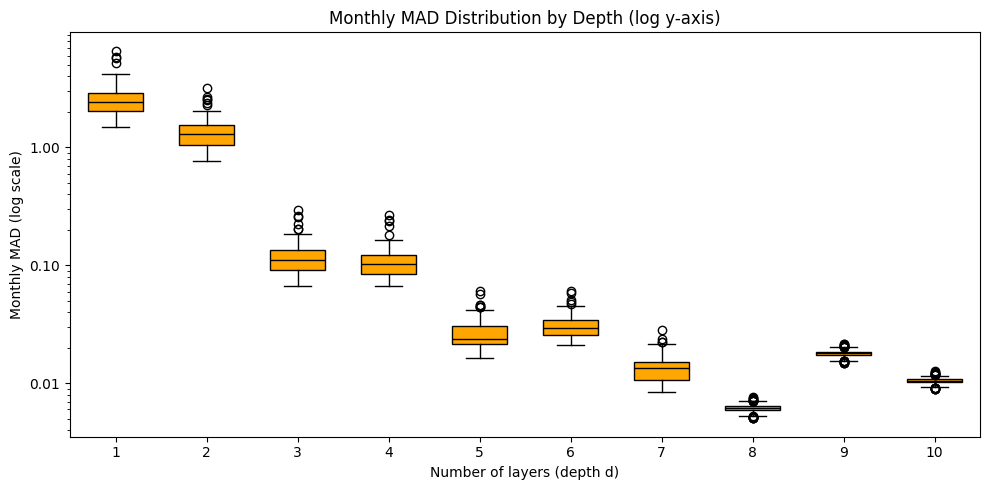

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Ensure numeric, ordered depths
mw = monthly_wide.copy()
mw.columns = mw.columns.astype(int)
mw = mw.reindex(sorted(mw.columns), axis=1)

depths = mw.columns.tolist()
data = [mw[d].dropna().values for d in depths]

fig, ax = plt.subplots(figsize=(10, 5))

bp = ax.boxplot(
    data,
    labels=depths,
    patch_artist=True,
    showfliers=True,
    widths=0.6
)

# Color all boxes orange
for box in bp["boxes"]:
    box.set_facecolor('orange')
    box.set_alpha(.99)

# Make medians visible
for med in bp["medians"]:
    med.set_linewidth(1)
    med.set_color('black')

ax.set_xlabel("Number of layers (depth d)")
ax.set_ylabel("Monthly MAD (log scale)")
ax.set_title("Monthly MAD Distribution by Depth (log y-axis)")
ax.set_yscale("log")
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
ax.grid(True, which="both", axis="y", alpha=0.3)
# remove grid in the background
plt.grid(False, which="both", axis="both")
plt.tight_layout()
plt.show()

# Decile Portfolio Time Series: SCG Factor

In [ ]:
split_yyyymm = '201612'

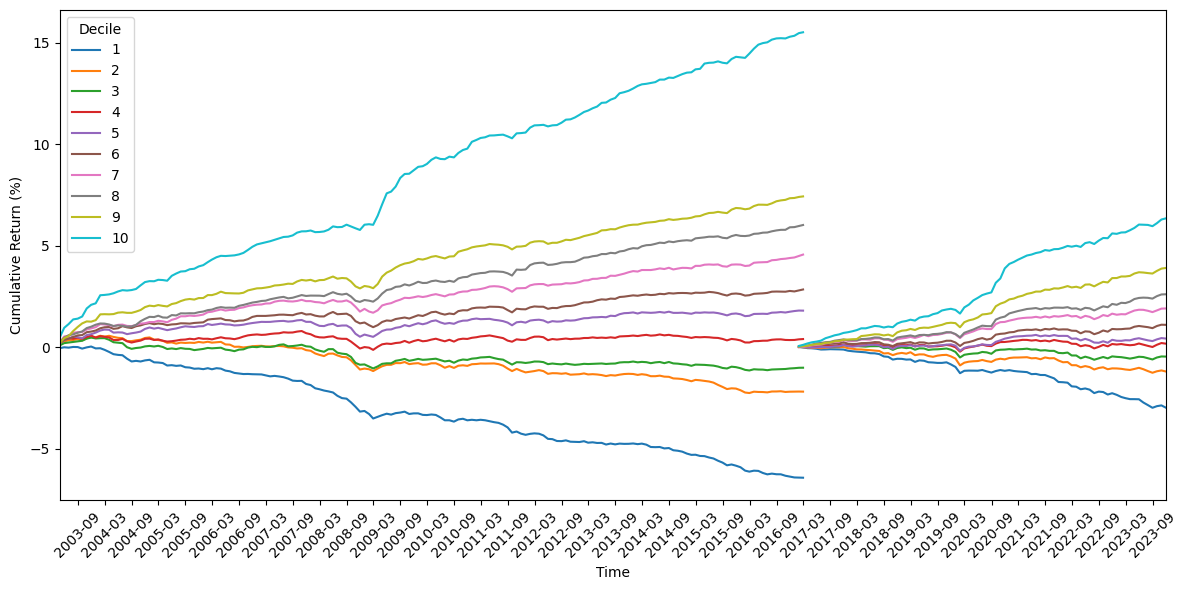

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# keep the first 167 rows
deciles_train=deciles.iloc[:167, :]
deciles_ls_train=deciles_ls.iloc[:167]

deciles_test=deciles.iloc[167:, :]
deciles_ls_test=deciles_ls.iloc[167:]

# Calculate cumulative returns for each decile

cumulative_train = (1 + deciles_train/100).cumprod() - 1
cumulative_ls_train = (1 + deciles_ls_train/100).cumprod() - 1

cumulative_test = (1 + deciles_test/100).cumprod() - 1
cumulative_ls_test = (1 + deciles_ls_test/100).cumprod() - 1

# cumulative is cumulative returns DataFrame
n_periods_train = cumulative_train.shape[0]  # number of rows
n_periods_test = cumulative_test.shape[0]  # number of rows

# create row indices that correspond to yyyy-mm starting in 2003-04 for cumulative
cumulative_train.index = pd.date_range(start='2003-04', periods=n_periods_train, freq='ME')
cumulative_ls_train.index = pd.date_range(start='2003-04', periods=n_periods_train, freq='ME')

cumulative_test.index = pd.date_range(start='2017-01', periods=n_periods_test, freq='ME')
cumulative_ls_test.index = pd.date_range(start='2017-01', periods=n_periods_test, freq='ME')

plt.figure(figsize=(12, 6))
for col in cumulative_train.columns:
    plt.plot(cumulative_train.index, cumulative_train[col]*100, label=int(col)+1)

for col in cumulative_test.columns:
    plt.plot(cumulative_test.index, cumulative_test[col]*100)#, label=int(col)+1)

# make sure the x axis begins at 2003-04
plt.xlim(cumulative_train.index[0], cumulative_test.index[-1])

# add vertical line at index 167
plt.axvline(x=167, color='red', linestyle='--')

# add deciles_ls dataframe time series
#plt.plot(cumulative_ls.index, cumulative_ls*100, label='LS Portfolio', color='green', linestyle='--')

#plt.title("Cumulative Decile Portfolio Returns (Train Set)")
plt.xlabel("Time")
plt.ylabel("Cumulative Return (%)")
plt.legend(title="Decile")
plt.grid(False)


plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=6))  # every 6 months
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Asset Pricing Tests

## Time Series Regressions Against Test Assets

In [ ]:
T = ff5_lagged.shape[0]  # number of time points
start_date = '1977-01'
yyyymm = pd.date_range(start=start_date, periods=T, freq='M').strftime('%Y%m').astype(int)

# make yyyymm the index for ff5_lagged and french_25_np
ff5_lagged = pd.DataFrame(ff5_lagged, index=yyyymm)

# keep only yyyymm after and including 200304
ff5_lagged = ff5_lagged.loc[200304:]

ff5_lagged=ff5_lagged.to_numpy()

In [ ]:
# Our asset pricing factor (d=3)
scg_factor=pd.read_csv('../data/factset_tests/factset_asset_pricing_factor_factor_decile_time_series_3_LAYER_LS_top_minus_bottom.csv')

# remove last row
scg_factor=scg_factor.iloc[:-1, 1]
scg_factor=scg_factor.to_numpy()

In [ ]:
# Regression Against French 25

#french_25=pd.read_csv('../data/french_25.csv')
french_25=pd.read_csv('../data/french_30_industry_eq_weighted.csv')
##french_25=pd.read_csv('../data/aipt_13_themes_factors.csv')
##french_25 = french_25[(french_25["date"] >= 197701) & (french_25["date"] <= 202401)].reset_index(drop=True)
french_25 = french_25.iloc[621:1186, :]
french_25 = french_25.iloc[:, 1:]  # Drop the first column
french_25_np=french_25.to_numpy()
french_25_np=french_25_np[:-1]
french_25_np=french_25_np.astype(float)

In [ ]:
french_25_np.shape

(564, 30)

In [ ]:
T = french_25_np.shape[0]  # number of time points
start_date = '1977-01'
yyyymm = pd.date_range(start=start_date, periods=T, freq='M').strftime('%Y%m').astype(int)

In [ ]:
french_25_labels = [
    "SMALL LoBM", "ME1 BM2", "ME1 BM3", "ME1 BM4", "SMALL HiBM", "ME2 BM1",
    "ME2 BM2", "ME2 BM3", "ME2 BM4", "ME2 BM5", "ME3 BM1", "ME3 BM2",
    "ME3 BM3", "ME3 BM4", "ME3 BM5", "ME4 BM1", "ME4 BM2", "ME4 BM3",
    "ME4 BM4", "ME4 BM5", "BIG LoBM", "ME5 BM2", "ME5 BM3", "ME5 BM4",
    "BIG HiBM"
]

In [ ]:
french_25_labels = [
    'Food', 'Beer', 'Smoke', 'Games', 'Books', 'Hshld', 'Clths', 'Hlth',
    'Chems', 'Txtls', 'Cnstr', 'Steel', 'FabPr', 'ElcEq', 'Autos', 'Carry',
    'Mines', 'Coal', 'Oil', 'Util', 'Telcm', 'Servs', 'BusEq', 'Paper',
    'Trans', 'Whlsl', 'Rtail', 'Meals', 'Fin', 'Other'
]

In [ ]:
french_25_labels = [
    'accruals', 'debt_issuance','investment','low_leverage','low_risk',
    'momentum','profit_growth','profitability','quality','seasonality',
  'short_term_reversal','size','value'
]

In [ ]:
# make yyyymm the index for ff5_lagged and french_25_np
ff5_lagged = pd.DataFrame(ff5_lagged, index=yyyymm)
french_25_np = pd.DataFrame(french_25_np, index=yyyymm)

In [ ]:
# keep only yyyymm after and including 200304
ff5_lagged = ff5_lagged.loc[200304:]
french_25_np = french_25_np.loc[200304:]

In [ ]:
french_25_np=french_25_np.to_numpy()
ff5_lagged=ff5_lagged.to_numpy()

In [ ]:
## MLP 3 as control instead of FF5
ff5=pd.read_csv('../data/factset_tests/MLP/LS_9_minus_0_factset_decile_pca_asset_pricing_factors_40_dim_MLP_3_hidden_layers_dropout0_lr_0.001_L2_0.0001_batch_32.csv')

# keep only second column and turn into numpy matrix (nx1)
ff5=ff5.iloc[:, 1]
ff5=ff5.to_numpy()
ff5=ff5.reshape(-1, 1)

# remove last row
ff5=ff5[:-1]

ff5_lagged=ff5

In [ ]:
import os
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from scipy import stats

def french_25_reg(french_25_labels, french_25_np, ff5_lagged):
    model_names = ['Transformer']
    epoch_grid = [80]
    layer_values = [3]
    dim_values = [40]
    dropout_rates = [0.3]
    num_heads = [2]

    for model_name in model_names:
        for layer in layer_values:
            for head in num_heads:
                for dim in dim_values:
                    for drop in dropout_rates:
                        for epoch in epoch_grid:

                            #residuals_path = f'../data/SINGLE_no_reg_out_asset_pricing_factors_{model_name}_All_firms_layers_{layer}_heads_{head}_embed_dim_{dim}_dropout_{drop}_epochs_{epoch}.csv'
                            residuals_path = f'../data/factset_tests/LS_9_minus_0_factset_decile_pca_asset_pricing_factors_{model_name}_All_firms_layers_{layer}_heads_{head}_embed_dim_{dim}_dropout_{drop}_epochs_{epoch}.csv'

                            if not os.path.exists(residuals_path):
                                print(f"File for {model_name} with {layer} layers and {dim} embedding dimensions not found.")
                                continue

                            residuals_matrix = pd.read_csv(residuals_path, index_col=0)

                            # remove last row
                            residuals_matrix = residuals_matrix.iloc[:-1, :]

                            # Concatenate residuals_matrix and ff5_lagged to form the full covariate matrix
                            covariates_matrix = np.hstack([residuals_matrix, ff5_lagged])
                            XtX_inv = np.linalg.inv(covariates_matrix.T @ covariates_matrix)

                            # Regress the 25 sorted portfolios on the full set of covariates
                            N = french_25_np.shape[1]
                            K = covariates_matrix.shape[1]
                            T = french_25_np.shape[0]
                            beta_matrix = np.full((N, K), np.nan)
                            t_stats_matrix = np.full((N, K), np.nan)


                            for i in range(N):
                                x_valid = french_25_np[:, i]
                                model = LinearRegression(fit_intercept=False)
                                model.fit(covariates_matrix, x_valid)
                                beta_matrix[i, :] = model.coef_
                                #t_stats_matrix[i, :] = model.coef_ / np.std(x_valid) * np.sqrt(covariates_matrix.shape[0])
                                residuals = x_valid - model.predict(covariates_matrix)
                                sigma2 = np.var(residuals, ddof=K)
                                t_stats_matrix[i, :] = model.coef_ / np.sqrt(sigma2) * np.sqrt(covariates_matrix.shape[0])


                            # Save first-pass t-stats to CSV
                            #t_stats_matrix_df = pd.DataFrame(t_stats_matrix[:, :40], index=french_25_labels)
                            t_stats_matrix_df = pd.DataFrame(t_stats_matrix, index=french_25_labels)
                            t_stats_matrix_df.to_csv(f'../data/factset_tests/factset_AIPT_13_test_t_stats_matrix_{model_name}_layers_{layer}_heads_{head}_embed_dim_{dim}_dropout_{drop}_epochs_{epoch}.csv')

                            #k = 6  # <-- choose your desired number of factors to keep
                            k=np.shape(beta_matrix)[1]

                            # Step 1: compute mean absolute t-stat for each factor
                            #mean_abs_t_stats = np.mean(np.abs(t_stats_matrix[:, :40]), axis=0)
                            mean_abs_t_stats = np.mean(np.abs(t_stats_matrix), axis=0)

                            # Step 2: get indices of top k factors
                            #top_k_indices = np.argsort(mean_abs_t_stats)[-k:]

                            # Step 3: subset beta_matrix to keep only top-k factors
                            #beta_matrix_topk = beta_matrix[:, top_k_indices]
                            beta_matrix_topk = beta_matrix

                            #top_k_factor_names = [f"Factor_{i+1}" for i in top_k_indices]
                            top_k_factor_names = [f"FF_{i}" for i in range(beta_matrix_topk.shape[1])]
                            top_k_factor_names[0]="Factor_SCG"

                            # Second pass: Fama-MacBeth cross-sectional regressions
                            lambda_t_series = np.full((T, k), np.nan)
                            lambda_t_stats = np.full((T, k), np.nan)

                            for t in range(T):
                                y_t = french_25_np[t, :]
                                X = beta_matrix_topk
                                K_top = X.shape[1]

                                model = LinearRegression(fit_intercept=False)
                                model.fit(X, y_t)
                                lambda_hat = model.coef_
                                lambda_t_series[t, :] = lambda_hat

                                residuals = y_t - model.predict(X)
                                sigma2 = np.var(residuals, ddof=K_top)
                                XtX_inv = np.linalg.inv(X.T @ X)
                                var_lambda = sigma2 * XtX_inv
                                se_lambda = np.sqrt(np.diag(var_lambda))
                                lambda_t_stats[t, :] = lambda_hat / se_lambda

                            # Save time-series t-stats for lambda to CSV
                            df_lambda_t_stats = pd.DataFrame(lambda_t_stats, columns=top_k_factor_names)
                            #df_lambda_t_stats.to_csv(f"../data/lambda_t_stats_timeseries_layers_{layer}_dim_{dim}_dropout_{drop}_epochs_{epoch}.csv", index=False)

                            # Save lambda_t_series
                            df_lambda_t_series = pd.DataFrame(lambda_t_series, columns=top_k_factor_names)
                            #df_lambda_t_series.to_csv(f"../data/lambda_t_series_layers_{layer}_dim_{dim}_dropout_{drop}_epochs_{epoch}.csv", index=False)

                            # Compute and save lambda_bar and t-statistics
                            lambda_bar = np.mean(lambda_t_series, axis=0)
                            lambda_se = np.std(lambda_t_series, axis=0, ddof=1) / np.sqrt(T)
                            lambda_bar_t = lambda_bar / lambda_se
                            df_summary = pd.DataFrame({
                                "lambda_bar": lambda_bar,
                                "SE": lambda_se,
                                "t_stat": lambda_bar_t
                            }, index=top_k_factor_names)
                            #df_summary.to_csv(f"../data/lambda_bar_summary_layers_{layer}_dim_{dim}_dropout_{drop}_epochs_{epoch}.csv")


In [ ]:
french_25_reg(french_25_labels, french_25_np, ff5_lagged)

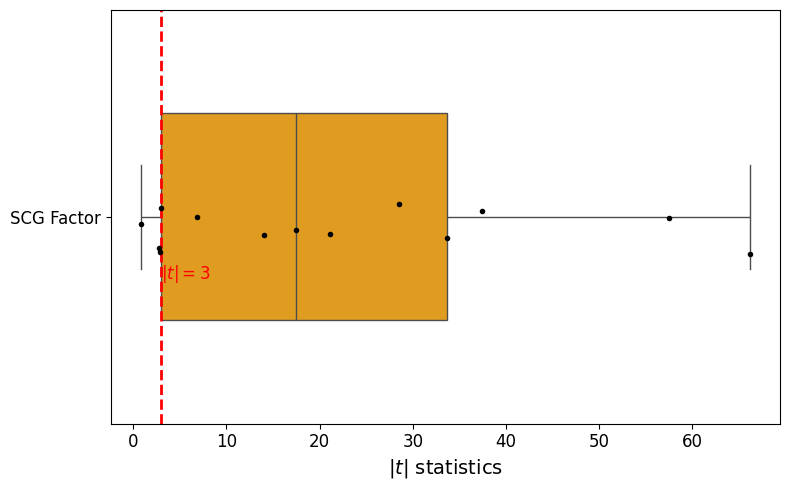

In [ ]:
# make boxplot of the t stats matrix
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#t_stats=pd.read_csv('../data/factset_tests/factset_industry_test_t_stats_matrix_Transformer_layers_3_heads_2_embed_dim_40_dropout_0.3_epochs_80.csv')
t_stats=pd.read_csv('../data/factset_tests/factset_AIPT_13_test_t_stats_matrix_Transformer_layers_3_heads_2_embed_dim_40_dropout_0.3_epochs_80.csv')

# boxlot of first column with absolute value t stats in x axis
t_stats = t_stats.iloc[:, 1]
t_stats = np.abs(t_stats)

plt.figure(figsize=(8, 5))

# Make a horizontal boxplot
sns.boxplot(x=t_stats, color="orange", orient="h", width=0.5, showfliers=False)

# Overlay individual data points
sns.stripplot(x=t_stats, color="black", size=4, orient="h", jitter=True)


# Add vertical line for |t| = 3
plt.axvline(3, color="red", linestyle="--", linewidth=2)

# Axis labels with LaTeX style
plt.xlabel(r"$|t|$ statistics", fontsize=14)
plt.yticks([0], [r"SCG Factor"], fontsize=12)  # since only one factor
plt.xticks(fontsize=12)

# Add text annotation for |t|=3
plt.text(3, 0.15, r"$|t| = 3$", color="red", fontsize=12, ha="left")

plt.tight_layout()
plt.show()

## Hansen-Jagannathan Distance

In [ ]:
## HJD
import numpy as np

def month_to_row(yyyymm_start: int, yyyymm_target: int) -> int:
    """0-based row index of yyyymm_target, assuming monthly contiguous data starting at yyyymm_start."""
    y0, m0 = divmod(yyyymm_start, 100)
    y1, m1 = divmod(yyyymm_target, 100)
    return 12 * (y1 - y0) + (m1 - m0)

def hjd_oos_from_returns_by_split(r, x, train_end_row, ridge=1e-8, use_pinv=True):
    """
    r: (T, N) test asset returns (FF25)
    x: (T, K) factor/control matrix
    train_end_row: last training row index (inclusive)
    """
    r_train = r[:train_end_row+1, :]
    r_test  = r[train_end_row+1:, :]
    x_train = x[:train_end_row+1, :]
    x_test  = x[train_end_row+1:, :]

    T_train = x_train.shape[0]
    mu_r = r_train.mean(axis=0)                       # (N,)
    G = (r_train.T @ x_train) / T_train               # (N, K)

    B_train = (r_train.T @ r_train) / T_train
    B_train = B_train + ridge * np.eye(B_train.shape[0])
    B_inv = np.linalg.pinv(B_train) if use_pinv else np.linalg.inv(B_train)

    A = G.T @ B_inv @ G
    A = A + ridge * np.eye(A.shape[0])
    b_hat = np.linalg.solve(A, G.T @ B_inv @ mu_r)    # (K,)

    m_test = 1.0 - (x_test @ b_hat)                   # (T_test,)
    e_os = (r_test.T @ m_test) / r_test.shape[0]      # (N,)

    B_os = (r_test.T @ r_test) / r_test.shape[0]
    B_os = B_os + ridge * np.eye(B_os.shape[0])
    B_os_inv = np.linalg.pinv(B_os) if use_pinv else np.linalg.inv(B_os)

    hjd2_os = float(e_os.T @ B_os_inv @ e_os)
    hjd_os = float(np.sqrt(np.clip(hjd2_os, 0.0, None)))

    return {"b_hat": b_hat, "e_os": e_os, "hjd2_os": hjd2_os, "hjd_os": hjd_os}

yyyymm_start = 200304
yyyymm_train_end = 201612

train_end_row = month_to_row(yyyymm_start, yyyymm_train_end)

residuals_path = f'../data/factset_tests/LS_9_minus_0_factset_decile_pca_asset_pricing_factors_Transformer_All_firms_layers_3_heads_2_embed_dim_40_dropout_0.3_epochs_80.csv'
residuals_matrix = pd.read_csv(residuals_path, index_col=0)
# remove last row
residuals_matrix = residuals_matrix.iloc[:-1, :]

# Baseline: FF5 only
x0 = ff5_lagged  # (T,5)
res0 = hjd_oos_from_returns_by_split(french_25_np, x0, train_end_row)

# Augmented: GNN + FF5
x1 = np.hstack([residuals_matrix.to_numpy(), ff5_lagged])
res1 = hjd_oos_from_returns_by_split(french_25_np, x1, train_end_row)

print("Train end row (inclusive):", train_end_row)
print("OOS HJD (FF5 only):", res0["hjd_os"], " (squared:", res0["hjd2_os"], ")")
print("OOS HJD (GNN+FF5):", res1["hjd_os"], " (squared:", res1["hjd2_os"], ")")
print("Percent reduction:", 100*(res0["hjd_os"] - res1["hjd_os"]) / res0["hjd_os"])

Train end row (inclusive): 164
OOS HJD (FF5 only): 0.337996424640845  (squared: 0.1142415830699944 )
OOS HJD (GNN+FF5): 0.33745241748091603  (squared: 0.11387413406371444 )
Percent reduction: 0.16095056641709568


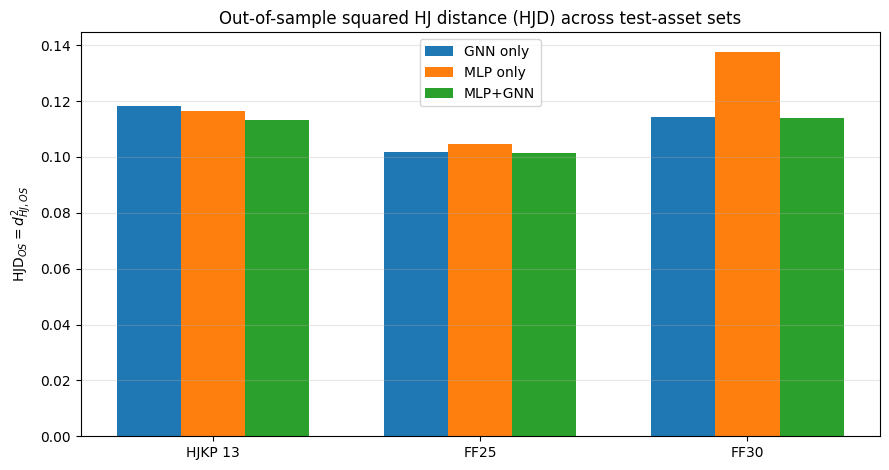

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Data
# -----------------------------
datasets = ["HJKP 13", "FF25", "FF30"]
models = ["GNN only", "MLP only", "MLP+GNN"]  # order you requested

# d_{HJ,OS}
d_vals = {
    "HJKP 13": {"MLP only": 0.3410, "GNN only": 0.3439, "GNN + MLP": 0.3363},
    "FF25":    {"MLP only": 0.3235, "GNN only": 0.3189, "GNN + MLP": 0.3183},
    "FF30":    {"MLP only": 0.3711, "GNN only": 0.3379, "GNN + MLP": 0.3374},
}

# squared HJD = d^2 (as reported in your tables)
hjd_vals = {
    "HJKP 13": {"MLP only": 0.1163, "GNN only": 0.1182, "GNN + MLP": 0.1131},
    "FF25":    {"MLP only": 0.1046, "GNN only": 0.1017, "GNN + MLP": 0.1013},
    "FF30":    {"MLP only": 0.1377, "GNN only": 0.1142, "GNN + MLP": 0.1138},
}

def make_grouped_barplot(metric_dict, title, ylabel):
    x = np.arange(len(datasets))
    width = 0.24

    # map requested model labels to your dict keys
    key_map = {
        "GNN only": "GNN only",
        "MLP only": "MLP only",
        "MLP+GNN": "GNN + MLP",
    }

    fig, ax = plt.subplots(figsize=(9, 4.8))

    for j, m in enumerate(models):
        vals = [metric_dict[ds][key_map[m]] for ds in datasets]
        ax.bar(x + (j - 1) * width, vals, width, label=m)

    ax.set_xticks(x)
    ax.set_xticklabels(datasets)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()
    ax.margins(x=0.05)

    # light y-grid only (optional). Comment out if you don't want any grid.
    ax.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    return fig, ax

# 1) Plot for d_{HJ,OS}
#make_grouped_barplot(
#    d_vals,
#    title="Out-of-sample HJ distance (d) across test-asset sets",
#    ylabel=r"$d_{HJ,OS}$"
#)

# 2) Plot for squared distance HJD
make_grouped_barplot(
    hjd_vals,
    title="Out-of-sample squared HJ distance (HJD) across test-asset sets",
    ylabel=r"$\mathrm{HJD}_{OS}=d_{HJ,OS}^2$"
)

plt.show()

## Spanning Regressions

In [ ]:
#### Spanning Predictions Regressions ######
predictions_gnn=pd.read_csv(f'../data/factset_tests/factset_decile_chars_test_corrections_Transformer_All_firms_layers_10_dim_40_epochs_50_l2_reg3.csv')
predictions_mlp=pd.read_csv(f'../data/factset_tests/MLP/40_dim_MLP_3_hidden_layers_test_corrections_dropout0_lr_0.001_L2_0.0001_batch_32.csv')

# drop first column in gnn
predictions_gnn=predictions_gnn.iloc[:, 1:]

In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm


def _check_unique_keys(df, keys, name):
    dup = df.duplicated(keys, keep=False)
    if dup.any():
        bad = df.loc[dup, keys].sort_values(keys)
        raise ValueError(
            f"{name} has duplicate yyyymm-firm pairs. "
            f"Need at most one row per ({keys}).\n"
            f"Examples:\n{bad.head(10)}"
        )


def run_gnn_nn3_spanning_regression(
    predictions_gnn: pd.DataFrame,
    predictions_mlp: pd.DataFrame,
    specification_name: str = "GNN(1) on NN3",
    gnn_col: str = "predicted_correction",
    mlp_col: str = "predicted_correction",
    time_col: str = "yyyymm",
    firm_col: str = "FACTSET_ENTITY_ID",
    nw_lags: int | None = None,
):
    """
    Runs the pooled panel regression

        yhat_GNN(it) = a_d + b_d * yhat_NN3(it) + u_it

    and saves the orthogonalized residual signal

        yhat_GNN_perp(it) = yhat_GNN(it) - a_d - b_d * yhat_NN3(it).

    Returns
    -------
    dict with:
        reg_df          : aligned dataframe used in the regression
        results         : statsmodels fitted results object
        final_row       : one-row DataFrame for the paper table
        residuals_df    : dataframe with saved residual signal
    """

    keys = [time_col, firm_col]

    gnn = predictions_gnn[[time_col, firm_col, gnn_col]].copy()
    mlp = predictions_mlp[[time_col, firm_col, mlp_col]].copy()

    gnn = gnn.rename(columns={gnn_col: "gnn_pred"})
    mlp = mlp.rename(columns={mlp_col: "mlp_pred"})

    _check_unique_keys(gnn, keys, "predictions_gnn")
    _check_unique_keys(mlp, keys, "predictions_mlp")

    # Keep only common firm-month observations
    reg_df = pd.merge(
        gnn,
        mlp,
        on=keys,
        how="inner",
        validate="one_to_one"
    )

    reg_df = reg_df.replace([np.inf, -np.inf], np.nan)
    reg_df = reg_df.dropna(subset=["gnn_pred", "mlp_pred"]).copy()

    if reg_df.empty:
        raise ValueError("No overlapping non-missing firm-month observations after merge.")

    # Sort before HAC
    reg_df = reg_df.sort_values([time_col, firm_col]).reset_index(drop=True)

    # Number of unique months
    T = reg_df[time_col].nunique()

    # Default Newey-West lag rule if not supplied
    if nw_lags is None:
        nw_lags = int(np.floor(4 * (T / 100) ** (2 / 9)))

    X = sm.add_constant(reg_df["mlp_pred"])
    y = reg_df["gnn_pred"]

    model = sm.OLS(y, X)
    results = model.fit(cov_type="HAC", cov_kwds={"maxlags": nw_lags})

    # Estimated coefficients
    a_hat = results.params["const"]
    b_hat = results.params["mlp_pred"]

    # Save residualized / orthogonalized GNN signal
    #reg_df["gnn_pred_perp"] = reg_df["gnn_pred"] - a_hat - b_hat * reg_df["mlp_pred"]
    reg_df["gnn_pred_perp"] = reg_df["gnn_pred"] - b_hat * reg_df["mlp_pred"]

    # This should match statsmodels residuals up to numerical precision
    reg_df["regression_residual"] = results.resid

    # Final one-row table for the paper
    final_row = pd.DataFrame({
        "Specification": [specification_name],
        "a_hat_d": [a_hat],
        "t(a_hat_d)": [results.tvalues["const"]],
        "b_hat_d": [b_hat],
        "t(b_hat_d)": [results.tvalues["mlp_pred"]],
        "R2": [results.rsquared],
    })

    # Residuals file/table
    residuals_df = reg_df[[time_col, firm_col, "gnn_pred", "mlp_pred", "gnn_pred_perp"]].copy()

    return {
        "reg_df": reg_df,
        "results": results,
        "final_row": final_row,
        "residuals_df": residuals_df,
        "nw_lags": nw_lags,
        "n_obs": int(results.nobs),
        "n_months": int(T),
    }

In [ ]:
res_1 = run_gnn_nn3_spanning_regression(
    predictions_gnn=predictions_gnn,
    predictions_mlp=predictions_mlp,
    specification_name="GNN(1) on NN3",
    gnn_col="predicted_correction",
    mlp_col="predicted_correction",
    time_col="yyyymm",
    firm_col="FACTSET_ENTITY_ID",
    nw_lags=None   # or set manually, e.g. 6, 12
)

print(res_1["final_row"])
print(res_1["residuals_df"].head())

   Specification   a_hat_d  t(a_hat_d)   b_hat_d  t(b_hat_d)            R2
0  GNN(1) on NN3  0.001403  550.108222 -0.000004   -0.158771  3.579334e-07
   yyyymm FACTSET_ENTITY_ID  gnn_pred  mlp_pred  gnn_pred_perp
0  201701          000C9Q-E  0.002162  0.021660       0.002162
1  201701          000HJP-E -0.000216 -0.007772      -0.000216
2  201701          000HSZ-E  0.002162  0.006405       0.002162
3  201701          000NXM-E  0.001389  0.021131       0.001389
4  201701          000QTC-E -0.000216  0.001096      -0.000216


In [ ]:
residuals_layer1 = res_1["residuals_df"]
# drop columns gnn_pred and mlp_pred
residuals_layer1 = residuals_layer1.drop(columns=["gnn_pred", "mlp_pred"])

residuals_layer1.to_csv("../data/factset_tests/spanning_reg_gnn_10_vs_mlp_3_residualized_signal_NO_intercept.csv", index=False)

In [ ]:
#### Spanning regressions GNN vs ALL
predictions_pca=pd.read_csv('../data/macro_chars_tests_regular/macro_firm_level_reg_pca_predictions_ALL_firms.csv')
#predictions_rppca=pd.read_csv('../data/macro_chars_tests_regular/macro_firm_level_reg_rppca_predictions_ALL_firms.csv')
predictions_ff=pd.read_csv('../data/firm_level_reg_ff5_predictions_ALL_firms.csv')
predictions_nc_ridge=pd.read_csv('../data/factset_tests/factset_macro_DECILE_firm_level_NC_ridge_predictions_ALL_firms.csv')
predictions_nc_lasso=pd.read_csv('../data/factset_tests/factset_macro_DECILE_firm_level_NC_lasso_predictions_ALL_firms.csv')

predictions_gnn=pd.read_csv(f'../data/factset_tests/factset_decile_chars_test_corrections_Transformer_All_firms_layers_10_dim_40_epochs_50_l2_reg3.csv')

predictions_mlp_2=pd.read_csv(f'../data/factset_tests/MLP/40_dim_MLP_2_hidden_layers_test_corrections_dropout0_lr_0.001_L2_0.0001_batch_32.csv')
predictions_mlp_3=pd.read_csv(f'../data/factset_tests/MLP/40_dim_MLP_3_hidden_layers_test_corrections_dropout0_lr_0.001_L2_0.0001_batch_32.csv')

# drop first column in gnn
predictions_gnn=predictions_gnn.iloc[:, 1:]

# from df construct a new dataframe that has yyyymm, gvkey, and FACTSET_ENTITY_ID as columns, and drop duplicates
factset_gvkey_map=df[['yyyymm', 'FACTSET_ENTITY_ID', 'gvkey']].drop_duplicates()

In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm


# ============================================================
# 0) Basic helpers
# ============================================================

def _coerce_yyyymm(s):
    """
    Convert a yyyymm-like series to integer yyyymm.
    """
    return pd.to_numeric(s, errors="coerce").astype("Int64")


def _check_unique_keys(df, keys, name):
    dup = df.duplicated(keys, keep=False)
    if dup.any():
        bad = df.loc[dup, keys].sort_values(keys)
        raise ValueError(
            f"{name} has duplicate rows on keys {keys}.\n"
            f"Examples:\n{bad.head(10)}"
        )


def _safe_entity_str(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip()
    return x if x != "" else np.nan


# ============================================================
# 1) Build the reference month set from GNN / MLP files
# ============================================================

def get_reference_months(predictions_gnn, predictions_mlp_2, predictions_mlp_3, time_col="yyyymm"):
    """
    Use the common months across GNN / MLP2 / MLP3 as the master month set.
    """
    months_gnn = set(_coerce_yyyymm(predictions_gnn[time_col]).dropna().astype(int).unique())
    months_mlp2 = set(_coerce_yyyymm(predictions_mlp_2[time_col]).dropna().astype(int).unique())
    months_mlp3 = set(_coerce_yyyymm(predictions_mlp_3[time_col]).dropna().astype(int).unique())

    ref_months = sorted(months_gnn & months_mlp2 & months_mlp3)

    if len(ref_months) == 0:
        raise ValueError("No common months across predictions_gnn, predictions_mlp_2, predictions_mlp_3.")

    return ref_months


# ============================================================
# 2) Prepare the gvkey <-> FACTSET_ENTITY_ID map
# ============================================================

def prepare_factset_gvkey_map(factset_gvkey_map):
    """
    Input expected columns:
        yyyymm, FACTSET_ENTITY_ID, gvkey

    Output:
        cleaned unique mapping by month and gvkey to FACTSET_ENTITY_ID
    """
    out = factset_gvkey_map.copy()

    needed = ["yyyymm", "FACTSET_ENTITY_ID", "gvkey"]
    missing = [c for c in needed if c not in out.columns]
    if missing:
        raise ValueError(f"factset_gvkey_map is missing columns: {missing}")

    out = out[needed].copy()
    out["yyyymm"] = _coerce_yyyymm(out["yyyymm"])
    out["FACTSET_ENTITY_ID"] = out["FACTSET_ENTITY_ID"].map(_safe_entity_str)
    out["gvkey"] = out["gvkey"].astype(str).str.strip()

    out = out.dropna(subset=["yyyymm", "FACTSET_ENTITY_ID", "gvkey"]).copy()
    out["yyyymm"] = out["yyyymm"].astype(int)

    # Drop exact duplicates
    out = out.drop_duplicates()


    counts = out.groupby(["yyyymm", "gvkey"])["FACTSET_ENTITY_ID"].nunique().reset_index(name="n_ids")
    good = counts.loc[counts["n_ids"] == 1, ["yyyymm", "gvkey"]]

    out = out.merge(good, on=["yyyymm", "gvkey"], how="inner")
    out = out.drop_duplicates(subset=["yyyymm", "gvkey"])

    _check_unique_keys(out, ["yyyymm", "gvkey"], "prepared factset_gvkey_map")

    return out


# ============================================================
# 3) Convert already-panel predictions (GNN / MLP2 / MLP3)
# ============================================================

def prepare_panel_predictions(
    df,
    signal_name,
    value_col="predicted_correction",
    time_col="yyyymm",
    firm_col="FACTSET_ENTITY_ID",
    keep_months=None,
):
    """
    Standardize an already-panel prediction dataframe to:
        yyyymm, FACTSET_ENTITY_ID, <signal_name>
    """
    needed = [time_col, firm_col, value_col]
    missing = [c for c in needed if c not in df.columns]
    if missing:
        raise ValueError(f"{signal_name}: missing columns {missing}")

    out = df[[time_col, firm_col, value_col]].copy()
    out = out.rename(columns={time_col: "yyyymm", firm_col: "FACTSET_ENTITY_ID", value_col: signal_name})

    out["yyyymm"] = _coerce_yyyymm(out["yyyymm"])
    out["FACTSET_ENTITY_ID"] = out["FACTSET_ENTITY_ID"].map(_safe_entity_str)

    out = out.dropna(subset=["yyyymm", "FACTSET_ENTITY_ID", signal_name]).copy()
    out["yyyymm"] = out["yyyymm"].astype(int)

    if keep_months is not None:
        out = out.loc[out["yyyymm"].isin(keep_months)].copy()

    _check_unique_keys(out, ["yyyymm", "FACTSET_ENTITY_ID"], signal_name)

    return out


# ============================================================
# 4) Convert wide predictions with gvkey columns -> panel FACTSET_ENTITY_ID
#    For PCA / FF5
# ============================================================

def prepare_wide_gvkey_predictions(
    df_wide,
    signal_name,
    gvkey_map,
    time_col="yyyymm",
    keep_months=None,
):
    """
    Input wide format:
        one row per yyyymm
        columns are gvkey values
    Output panel:
        yyyymm, FACTSET_ENTITY_ID, <signal_name>
    """
    if time_col not in df_wide.columns:
        raise ValueError(f"{signal_name}: expected '{time_col}' column in wide dataframe.")

    out = df_wide.copy()
    out[time_col] = _coerce_yyyymm(out[time_col])
    out = out.dropna(subset=[time_col]).copy()
    out[time_col] = out[time_col].astype(int)

    if keep_months is not None:
        out = out.loc[out[time_col].isin(keep_months)].copy()

    id_vars = [time_col]
    value_vars = [c for c in out.columns if c not in id_vars]

    long_df = out.melt(
        id_vars=time_col,
        value_vars=value_vars,
        var_name="gvkey",
        value_name=signal_name
    )

    long_df["gvkey"] = long_df["gvkey"].astype(str).str.strip()
    long_df = long_df.dropna(subset=[signal_name]).copy()

    # rename the time column before merging so there is no ambiguity
    long_df = long_df.rename(columns={time_col: "yyyymm"})

    # merge gvkey -> FACTSET_ENTITY_ID by month
    long_df = long_df.merge(
        gvkey_map[["yyyymm", "gvkey", "FACTSET_ENTITY_ID"]],
        on=["yyyymm", "gvkey"],
        how="inner",
        validate="many_to_one"
    )

    long_df = long_df[["yyyymm", "FACTSET_ENTITY_ID", signal_name]].copy()

    long_df["FACTSET_ENTITY_ID"] = long_df["FACTSET_ENTITY_ID"].map(_safe_entity_str)
    long_df = long_df.dropna(subset=["yyyymm", "FACTSET_ENTITY_ID", signal_name]).copy()

    # If duplicates arise after mapping, average them
    long_df = (
        long_df.groupby(["yyyymm", "FACTSET_ENTITY_ID"], as_index=False)[signal_name]
        .mean()
    )

    _check_unique_keys(long_df, ["yyyymm", "FACTSET_ENTITY_ID"], signal_name)

    return long_df


# ============================================================
# 5) Convert wide predictions with FACTSET_ENTITY_ID columns -> panel
#    For NC Ridge / NC LASSO
# ============================================================

def prepare_wide_factset_predictions(
    df_wide,
    signal_name,
    time_col="yyyymm",
    keep_months=None,
):
    """
    Input wide format:
        one row per yyyymm
        columns are FACTSET_ENTITY_ID values
    Output panel:
        yyyymm, FACTSET_ENTITY_ID, <signal_name>
    """
    if time_col not in df_wide.columns:
        raise ValueError(f"{signal_name}: expected '{time_col}' column in wide dataframe.")

    out = df_wide.copy()
    out[time_col] = _coerce_yyyymm(out[time_col])
    out = out.dropna(subset=[time_col]).copy()
    out[time_col] = out[time_col].astype(int)

    if keep_months is not None:
        out = out.loc[out[time_col].isin(keep_months)].copy()

    id_vars = [time_col]
    value_vars = [c for c in out.columns if c not in id_vars]

    long_df = out.melt(
        id_vars=time_col,
        value_vars=value_vars,
        var_name="FACTSET_ENTITY_ID",
        value_name=signal_name
    )

    long_df["FACTSET_ENTITY_ID"] = long_df["FACTSET_ENTITY_ID"].map(_safe_entity_str)
    long_df = long_df.dropna(subset=["FACTSET_ENTITY_ID", signal_name]).copy()

    long_df = long_df.rename(columns={time_col: "yyyymm"})
    long_df = long_df[["yyyymm", "FACTSET_ENTITY_ID", signal_name]].copy()


    long_df = (
        long_df.groupby(["yyyymm", "FACTSET_ENTITY_ID"], as_index=False)[signal_name]
        .mean()
    )

    _check_unique_keys(long_df, ["yyyymm", "FACTSET_ENTITY_ID"], signal_name)

    return long_df


# ============================================================
# 6) Build one aligned regression dataframe
# ============================================================

def build_multivariate_spanning_dataframe(
    predictions_gnn,
    predictions_mlp_2,
    predictions_mlp_3,
    predictions_ff,
    predictions_pca,
    predictions_nc_ridge,
    predictions_nc_lasso,
    factset_gvkey_map,
):
    """
    Returns one merged panel dataframe with columns:
        yyyymm, FACTSET_ENTITY_ID,
        gnn_pred, nn2_pred, nn3_pred, ff5_pred, pca_pred,
        nc_ridge_pred, nc_lasso_pred
    """

    # Common months anchored to GNN/MLP files
    ref_months = get_reference_months(predictions_gnn, predictions_mlp_2, predictions_mlp_3)

    # Clean gvkey map
    gvkey_map = prepare_factset_gvkey_map(factset_gvkey_map)
    gvkey_map = gvkey_map.loc[gvkey_map["yyyymm"].isin(ref_months)].copy()

    # Panel-format files
    gnn_panel = prepare_panel_predictions(
        predictions_gnn,
        signal_name="gnn_pred",
        value_col="predicted_correction",
        time_col="yyyymm",
        firm_col="FACTSET_ENTITY_ID",
        keep_months=ref_months,
    )

    nn2_panel = prepare_panel_predictions(
        predictions_mlp_2,
        signal_name="nn2_pred",
        value_col="predicted_correction",
        time_col="yyyymm",
        firm_col="FACTSET_ENTITY_ID",
        keep_months=ref_months,
    )

    nn3_panel = prepare_panel_predictions(
        predictions_mlp_3,
        signal_name="nn3_pred",
        value_col="predicted_correction",
        time_col="yyyymm",
        firm_col="FACTSET_ENTITY_ID",
        keep_months=ref_months,
    )

    # Wide gvkey files
    ff5_panel = prepare_wide_gvkey_predictions(
        predictions_ff,
        signal_name="ff5_pred",
        gvkey_map=gvkey_map,
        time_col="yyyymm",
        keep_months=ref_months,
    )

    pca_panel = prepare_wide_gvkey_predictions(
        predictions_pca,
        signal_name="pca_pred",
        gvkey_map=gvkey_map,
        time_col="yyyymm",
        keep_months=ref_months,
    )

    # Wide FACTSET files
    ridge_panel = prepare_wide_factset_predictions(
        predictions_nc_ridge,
        signal_name="nc_ridge_pred",
        time_col="yyyymm",
        keep_months=ref_months,
    )

    lasso_panel = prepare_wide_factset_predictions(
        predictions_nc_lasso,
        signal_name="nc_lasso_pred",
        time_col="yyyymm",
        keep_months=ref_months,
    )

    # Inner merge everything so we keep exactly the common aligned panel
    reg_df = gnn_panel.merge(nn2_panel, on=["yyyymm", "FACTSET_ENTITY_ID"], how="inner", validate="one_to_one")
    reg_df = reg_df.merge(nn3_panel, on=["yyyymm", "FACTSET_ENTITY_ID"], how="inner", validate="one_to_one")
    reg_df = reg_df.merge(ff5_panel, on=["yyyymm", "FACTSET_ENTITY_ID"], how="inner", validate="one_to_one")
    reg_df = reg_df.merge(pca_panel, on=["yyyymm", "FACTSET_ENTITY_ID"], how="inner", validate="one_to_one")
    reg_df = reg_df.merge(ridge_panel, on=["yyyymm", "FACTSET_ENTITY_ID"], how="inner", validate="one_to_one")
    reg_df = reg_df.merge(lasso_panel, on=["yyyymm", "FACTSET_ENTITY_ID"], how="inner", validate="one_to_one")

    reg_df = reg_df.replace([np.inf, -np.inf], np.nan)
    reg_df = reg_df.dropna().copy()

    reg_df = reg_df.sort_values(["yyyymm", "FACTSET_ENTITY_ID"]).reset_index(drop=True)

    _check_unique_keys(reg_df, ["yyyymm", "FACTSET_ENTITY_ID"], "multivariate spanning reg_df")

    return reg_df


# ============================================================
# 7) Run the multivariate pooled spanning regression
# ============================================================

def run_multivariate_spanning_regression(
    reg_df,
    nw_lags=None,
    specification_name="GNN(3) on NN2, NN3, FF5, PCA, NC Ridge, NC LASSO",
):
    """
    Estimate:

        gnn_pred = a_multi + beta'z + u_multi

    Returns the economically meaningful outputs:
        - intercept estimate
        - NW t-stat for intercept
        - R2
        - residualized GNN signal
    """

    required = [
        "yyyymm", "FACTSET_ENTITY_ID", "gnn_pred",
        "nn2_pred", "nn3_pred", "ff5_pred", "pca_pred",
        "nc_ridge_pred", "nc_lasso_pred"
    ]
    missing = [c for c in required if c not in reg_df.columns]
    if missing:
        raise ValueError(f"reg_df is missing columns: {missing}")

    X_cols = ["nn2_pred", "nn3_pred", "ff5_pred", "pca_pred", "nc_ridge_pred", "nc_lasso_pred"]

    y = reg_df["gnn_pred"].astype(float)
    X = reg_df[X_cols].astype(float)
    X = sm.add_constant(X)

    T = reg_df["yyyymm"].nunique()
    if nw_lags is None:
        nw_lags = int(np.floor(4 * (T / 100) ** (2 / 9)))

    model = sm.OLS(y, X)
    results = model.fit(cov_type="HAC", cov_kwds={"maxlags": nw_lags})

    a_multi = results.params["const"]
    t_a_multi = results.tvalues["const"]

    out_df = reg_df.copy()
    #out_df["gnn_pred_perp_multi"] = results.resid
    X_cols = ["nn2_pred", "nn3_pred", "ff5_pred", "pca_pred", "nc_ridge_pred", "nc_lasso_pred"]
    beta_hat = results.params[X_cols]
    out_df["gnn_pred_perp_multi"] = (out_df["gnn_pred"]- out_df[X_cols].mul(beta_hat, axis=1).sum(axis=1))

    final_row = pd.DataFrame({
        "Specification": [specification_name],
        "a_multi_hat": [a_multi],
        "t(a_multi_hat)": [t_a_multi],
        "R2": [results.rsquared],
        "N": [int(results.nobs)],
        "T_months": [int(T)],
        "NW_lags": [int(nw_lags)],
    })

    residuals_df = out_df[
        [
            "yyyymm", "FACTSET_ENTITY_ID", "gnn_pred",
            "nn2_pred", "nn3_pred", "ff5_pred", "pca_pred",
            "nc_ridge_pred", "nc_lasso_pred",
            "gnn_pred_perp_multi"
        ]
    ].copy()

    return {
        "reg_df": out_df,
        "results": results,
        "final_row": final_row,
        "residuals_df": residuals_df,
    }


# ============================================================

reg_df_multi = build_multivariate_spanning_dataframe(
    predictions_gnn=predictions_gnn,
    predictions_mlp_2=predictions_mlp_2,
    predictions_mlp_3=predictions_mlp_3,
    predictions_ff=predictions_ff,
    predictions_pca=predictions_pca,
    predictions_nc_ridge=predictions_nc_ridge,
    predictions_nc_lasso=predictions_nc_lasso,
    factset_gvkey_map=factset_gvkey_map,
)

res_multi = run_multivariate_spanning_regression(
    reg_df=reg_df_multi,
    nw_lags=None,
    specification_name="GNN(3) on NN2, NN3, FF5, PCA, NC Ridge, NC LASSO"
)

print(res_multi["final_row"])
print(res_multi["residuals_df"].head())
print(res_multi["results"].summary())

                                      Specification  a_multi_hat  \
0  GNN(3) on NN2, NN3, FF5, PCA, NC Ridge, NC LASSO     0.001385   

   t(a_multi_hat)        R2      N  T_months  NW_lags  
0      348.644773  0.000757  42408        85        3  
   yyyymm FACTSET_ENTITY_ID  gnn_pred  nn2_pred  nn3_pred  ff5_pred  pca_pred  \
0  201701          000HSZ-E  0.002162  0.019391  0.006405  0.023607 -0.015692   
1  201701          0011MS-E  0.001610  0.021467  0.011692  0.008889  0.004526   
2  201701          0013TL-E  0.001270  0.029498  0.021766  0.007634  0.031640   
3  201701          0013YQ-E  0.001765  0.043831  0.036031  0.062321  0.017867   
4  201701          0014DV-E  0.001938  0.026788  0.015592  0.008889  0.004526   

   nc_ridge_pred  nc_lasso_pred  gnn_pred_perp_multi  
0       0.035764       0.035348             0.002153  
1       0.026034       0.026463             0.001606  
2       0.030983       0.032180             0.001266  
3       0.099067       0.100388             

# Multi-Step Transaction Cost Experiments

In [ ]:
import pandas as pd

def load_pred(train_path, test_path, new_name):
    train = pd.read_csv(train_path)
    test = pd.read_csv(test_path)

    for df in [train, test]:
        unnamed = [c for c in df.columns if str(c).startswith('Unnamed')]
        if unnamed:
            df.drop(columns=unnamed, inplace=True)

    pred = pd.concat([train, test], axis=0, ignore_index=True).copy()
    pred = pred.rename(columns={'predicted_correction': new_name})
    pred = pred[['FACTSET_ENTITY_ID', 'yyyymm', new_name]]
    pred = pred.drop_duplicates(subset=['FACTSET_ENTITY_ID', 'yyyymm'], keep='first')
    return pred


def lag_prediction_panel(pred_df, pred_col, lag=1,
                         id_col='FACTSET_ENTITY_ID',
                         date_col='yyyymm'):
    out = pred_df.copy()
    out = out.sort_values([id_col, date_col]).reset_index(drop=True)
    out[pred_col] = out.groupby(id_col)[pred_col].shift(lag)
    return out

In [ ]:
pred_files = {

    0: {
        'train': '../data/factset_tests/factset_decile_chars_train_corrections_Transformer_ALL_firms_layers_3_dim_40_epochs_50_l2_reg3.csv',
        'test':  '../data/factset_tests/factset_decile_chars_test_corrections_Transformer_All_firms_layers_3_dim_40_epochs_50_l2_reg3.csv'
    },

    1: {
        'train': '../data/3_lag_tests_factset/1_both_lag_factset_decile_chars_train_corrections_Transformer_ALL_firms_layers_3_dim_40_epochs_80_l2_reg3.csv',
        'test':  '../data/3_lag_tests_factset/1_both_lag_factset_decile_chars_test_corrections_Transformer_All_firms_layers_3_dim_40_epochs_80_l2_reg3.csv'
    },
    3: {
        'train': '../data/3_lag_tests_factset/both_lag_factset_decile_chars_train_corrections_Transformer_ALL_firms_layers_3_dim_40_epochs_80_l2_reg3.csv',
        'test':  '../data/3_lag_tests_factset/both_lag_factset_decile_chars_test_corrections_Transformer_All_firms_layers_3_dim_40_epochs_80_l2_reg3.csv'
    },
    6: {
        'train': '../data/3_lag_tests_factset/6_both_lag_factset_decile_chars_train_corrections_Transformer_ALL_firms_layers_3_dim_40_epochs_80_l2_reg3.csv',
        'test':  '../data/3_lag_tests_factset/6_both_lag_factset_decile_chars_test_corrections_Transformer_All_firms_layers_3_dim_40_epochs_80_l2_reg3.csv'
    }
}

In [ ]:
import pandas as pd

def load_pred(train_path, test_path, new_name):
    train = pd.read_csv(train_path)
    test = pd.read_csv(test_path)

    for df in [train, test]:
        if 'Unnamed: 0' in df.columns:
            df.drop(columns=['Unnamed: 0'], inplace=True)

    pred = pd.concat([train, test], axis=0, ignore_index=True).copy()
    pred = pred.rename(columns={'predicted_correction': new_name})
    pred = pred[['FACTSET_ENTITY_ID', 'yyyymm', new_name]]
    pred = pred.drop_duplicates(subset=['FACTSET_ENTITY_ID', 'yyyymm'], keep='first')
    return pred

pred0 = load_pred(pred_files[0]['train'], pred_files[0]['test'], 'pred_lag0')
pred1 = load_pred(pred_files[1]['train'], pred_files[1]['test'], 'pred_lag1')
pred3 = load_pred(pred_files[3]['train'], pred_files[3]['test'], 'pred_lag3')
pred6 = load_pred(pred_files[6]['train'], pred_files[6]['test'], 'pred_lag6')

# Shift only the baseline/no-lag predictions by one month
pred0 = lag_prediction_panel(pred0, 'pred_lag0', lag=1)

same_month_df = df[['FACTSET_ENTITY_ID', 'yyyymm', 'mthret']].copy()
same_month_df = same_month_df.drop_duplicates(subset=['FACTSET_ENTITY_ID', 'yyyymm'], keep='first')

same_month_df = same_month_df.merge(pred0, on=['FACTSET_ENTITY_ID', 'yyyymm'], how='left')
same_month_df = same_month_df.merge(pred1, on=['FACTSET_ENTITY_ID', 'yyyymm'], how='left')
same_month_df = same_month_df.merge(pred3, on=['FACTSET_ENTITY_ID', 'yyyymm'], how='left')
same_month_df = same_month_df.merge(pred6, on=['FACTSET_ENTITY_ID', 'yyyymm'], how='left')

In [ ]:
import numpy as np
import pandas as pd

def _build_weights(pred: pd.Series) -> pd.Series:
    n = len(pred)
    if n == 0:
        return pd.Series(dtype=float)

    decile_size = max(1, n // 10)
    ranked = pred.rank(method='first')

    top_mask = ranked > (n - decile_size)
    bot_mask = ranked <= decile_size

    n1 = top_mask.sum()
    n2 = bot_mask.sum()

    w = pd.Series(0.0, index=pred.index)
    if n1 > 0:
        w[top_mask] =  1.0 / n1
    if n2 > 0:
        w[bot_mask] = -1.0 / n2
    return w

In [ ]:
def _precompute_signal(df, signal_col, date_col='yyyymm', id_col='FACTSET_ENTITY_ID', ret_col='mthret'):
    dates = np.sort(df[date_col].unique())
    W, F = {}, {}

    for d in dates:
        sub = df[df[date_col] == d][[id_col, signal_col, ret_col]].copy()
        sub = sub.dropna(subset=[signal_col, ret_col])

        if sub.empty:
            W[d] = pd.Series(dtype=float)
            F[d] = 0.0
            continue

        if sub.duplicated(subset=[id_col]).any():
            sub = sub.groupby(id_col, as_index=False).agg({
                signal_col: 'mean',
                ret_col: 'mean'
            })

        sub = sub.set_index(id_col)

        w = _build_weights(sub[signal_col])
        W[d] = w

        ret_vec = sub[ret_col].reindex(w.index, fill_value=0.0)
        F[d] = float((w * ret_vec).sum())

    return dates, W, F

In [ ]:
def _backtest_single_hold(dates, W, F, hold, k):
    """
    hold = rebalance every `hold` months
    """
    T = len(dates)
    rebal_idx = list(range(0, T, hold))

    block_gross, block_to, block_net = [], [], []

    for rb in rebal_idx:
        end = min(rb + hold - 1, T - 1)
        block_dates = dates[rb:end + 1]

        gross = 1.0
        for d in block_dates:
            gross *= (1.0 + F[d])
        gross -= 1.0

        next_rb = rb + hold
        if next_rb < T:
            w_curr = W[dates[rb]]
            w_next = W[dates[next_rb]]

            all_stk = w_curr.index.union(w_next.index)
            wc = w_curr.reindex(all_stk, fill_value=0.0)
            wn = w_next.reindex(all_stk, fill_value=0.0)
            to = float((wn - wc).abs().sum())
        else:
            to = 0.0

        net = gross - k * to

        block_gross.append(gross)
        block_to.append(to)
        block_net.append(net)

    return block_gross, block_to, block_net

In [ ]:
def decile_backtest_signal(df, signal_col, k, hold,
                           date_col='yyyymm',
                           id_col='FACTSET_ENTITY_ID',
                           ret_col='mthret'):
    dates, W, F = _precompute_signal(
        df, signal_col=signal_col,
        date_col=date_col, id_col=id_col, ret_col=ret_col
    )
    bg, bt, bn = _backtest_single_hold(dates, W, F, hold=hold, k=k)

    def ann(r_list):
        r = np.array(r_list, dtype=float)
        meq = r / hold
        return float(np.nanmean(meq))
        #return float(np.nanmean(meq) * 12)

    def ann_sr(r_list):
        r = np.array(r_list, dtype=float)
        meq = r / hold
        m = np.nanmean(meq)
        s = np.nanstd(meq, ddof=1)
        return float(m / s) if s > 0 else np.nan
        #return float(m / s * np.sqrt(12)) if s > 0 else np.nan

    return dict(
        turnover_mean=float(np.mean(bt)) if len(bt) else np.nan,
        gross_ann=ann(bg) if len(bg) else np.nan,
        net_ann=ann(bn) if len(bn) else np.nan,
        gross_sr=ann_sr(bg) if len(bg) else np.nan,
        net_sr=ann_sr(bn) if len(bn) else np.nan,
        block_gross=bg,
        block_net=bn,
        block_turnover=bt,
    )

In [ ]:
def decile_backtest_table_signal(df, signal_cols, k_values=None, hold_values=None,
                                 date_col='yyyymm',
                                 id_col='FACTSET_ENTITY_ID',
                                 ret_col='mthret'):
    if k_values is None:
        k_values = [0.0, 1e-4, 3e-4, 1e-3, 3e-3, 1e-2]
    if hold_values is None:
        hold_values = [1, 3, 6]

    rows = []

    for signal_col in signal_cols:
        dates, W, F = _precompute_signal(
            df, signal_col=signal_col,
            date_col=date_col, id_col=id_col, ret_col=ret_col
        )

        for hold in hold_values:
            bg, bt, _ = _backtest_single_hold(dates, W, F, hold=hold, k=0.0)

            bg_arr = np.array(bg, dtype=float)
            bt_arr = np.array(bt, dtype=float)

            def ann(r):
                meq = np.array(r, dtype=float) / hold
                return float(np.nanmean(meq))
                #return float(np.nanmean(meq) * 12)

            def ann_sr(r):
                meq = np.array(r, dtype=float) / hold
                m = np.nanmean(meq)
                s = np.nanstd(meq, ddof=1)
                return float(m / s ) if s > 0 else np.nan
                #return float(m / s * np.sqrt(12)) if s > 0 else np.nan

            for k in k_values:
                bn_arr = bg_arr - k * bt_arr
                rows.append({
                    'signal': signal_col,
                    'hold': hold,
                    'k': k,
                    'turnover_mean': float(bt_arr.mean()) if len(bt_arr) else np.nan,
                    'gross_ann': ann(bg_arr) if len(bg_arr) else np.nan,
                    'net_ann': ann(bn_arr) if len(bg_arr) else np.nan,
                    'gross_sr': ann_sr(bg_arr) if len(bg_arr) else np.nan,
                    'net_sr': ann_sr(bn_arr) if len(bg_arr) else np.nan,
                })

    return pd.DataFrame(rows).set_index(['signal', 'k', 'hold'])

In [ ]:
### NOT annualized ###
signal_cols = ['pred_lag0','pred_lag1', 'pred_lag3', 'pred_lag6']

results_same_month = decile_backtest_table_signal(
    same_month_df,
    signal_cols=signal_cols,
    k_values=[0.0, 1e-4, 3e-4, 1e-3, 3e-3, 1e-2],
    hold_values=[1, 1, 3, 6],
    date_col='yyyymm',
    id_col='FACTSET_ENTITY_ID',
    ret_col='mthret'
)

print(results_same_month)

                       turnover_mean  gross_ann   net_ann  gross_sr    net_sr
signal    k      hold                                                        
pred_lag0 0.0000 1          3.277349   0.011388  0.011388   0.15632  0.156320
          0.0001 1          3.277349   0.011388  0.011061   0.15632  0.151739
          0.0003 1          3.277349   0.011388  0.010405   0.15632  0.142592
          0.0010 1          3.277349   0.011388  0.008111   0.15632  0.110730
          0.0030 1          3.277349   0.011388  0.001556   0.15632  0.021017
...                              ...        ...       ...       ...       ...
pred_lag6 0.0001 6          3.316399   0.007335  0.007280   0.24112  0.239323
          0.0003 6          3.316399   0.007335  0.007169   0.24112  0.235730
          0.0010 6          3.316399   0.007335  0.006782   0.24112  0.223140
          0.0030 6          3.316399   0.007335  0.005677   0.24112  0.187081
          0.0100 6          3.316399   0.007335  0.001808   0.24

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

matched_map = {
    'pred_lag0': 1,
    'pred_lag1': 1,
    'pred_lag3': 3,
    'pred_lag6': 6,
}

def matched_label(signal_col):
    if signal_col == 'pred_lag0':
        return 'lag0'
    elif signal_col == 'pred_lag1':
        return 'lag1'
    elif signal_col == 'pred_lag3':
        return 'lag3'
    elif signal_col == 'pred_lag6':
        return 'lag6'
    return signal_col


def decile_backtest_table_matched(df, matched_map, k_values=None,
                                  date_col='yyyymm',
                                  id_col='FACTSET_ENTITY_ID',
                                  ret_col='mthret'):
    if k_values is None:
        k_values = [0.0, 1e-4, 3e-4, 1e-3, 3e-3, 1e-2]

    rows = []

    for signal_col, hold in matched_map.items():
        res0 = decile_backtest_signal(
            df,
            signal_col=signal_col,
            k=0.0,
            hold=hold,
            date_col=date_col,
            id_col=id_col,
            ret_col=ret_col
        )

        bg_arr = np.array(res0['block_gross'], dtype=float)
        bt_arr = np.array(res0['block_turnover'], dtype=float)

        def ann(r):
            meq = np.array(r, dtype=float) / hold
            return float(np.nanmean(meq))

        def ann_sr(r):
            meq = np.array(r, dtype=float) / hold
            m = np.nanmean(meq)
            s = np.nanstd(meq, ddof=1)
            return float(m / s) if s > 0 else np.nan

        for k in k_values:
            bn_arr = bg_arr - k * bt_arr
            rows.append({
                'signal': signal_col,
                'label': matched_label(signal_col),
                'hold': hold,
                'k': k,
                'turnover_mean': float(np.nanmean(bt_arr)) if len(bt_arr) else np.nan,
                'gross_ann': ann(bg_arr) if len(bg_arr) else np.nan,
                'net_ann': ann(bn_arr) if len(bg_arr) else np.nan,
                'gross_sr': ann_sr(bg_arr) if len(bg_arr) else np.nan,
                'net_sr': ann_sr(bn_arr) if len(bg_arr) else np.nan,
            })

    return pd.DataFrame(rows).set_index(['label', 'k'])


matched_results = decile_backtest_table_matched(
    same_month_df,
    matched_map=matched_map,
    k_values=[0.0, 1e-4, 3e-4, 1e-3, 3e-3, 1e-2],
    date_col='yyyymm',
    id_col='FACTSET_ENTITY_ID',
    ret_col='mthret'
)

print(matched_results)

                 signal  hold  turnover_mean  gross_ann   net_ann  gross_sr  \
label k                                                                       
lag0  0.0000  pred_lag0     1       3.277349   0.011388  0.011388  0.156320   
      0.0001  pred_lag0     1       3.277349   0.011388  0.011061  0.156320   
      0.0003  pred_lag0     1       3.277349   0.011388  0.010405  0.156320   
      0.0010  pred_lag0     1       3.277349   0.011388  0.008111  0.156320   
      0.0030  pred_lag0     1       3.277349   0.011388  0.001556  0.156320   
      0.0100  pred_lag0     1       3.277349   0.011388 -0.021385  0.156320   
lag1  0.0000  pred_lag1     1       3.335951   0.007730  0.007730  0.116005   
      0.0001  pred_lag1     1       3.335951   0.007730  0.007396  0.116005   
      0.0003  pred_lag1     1       3.335951   0.007730  0.006729  0.116005   
      0.0010  pred_lag1     1       3.335951   0.007730  0.004394  0.116005   
      0.0030  pred_lag1     1       3.335951   0.007

In [ ]:
def make_matched_summary_tables(matched_results):
    net_table = matched_results['net_ann'].unstack('label') * 100
    gross_table = matched_results['gross_ann'].unstack('label') * 100
    net_sr_table = matched_results['net_sr'].unstack('label')
    gross_sr_table = matched_results['gross_sr'].unstack('label')
    turnover_table = matched_results['turnover_mean'].unstack('label')

    # optional column order
    desired_order = ['lag0','lag1', 'lag3', 'lag6']
    for tbl in [net_table, gross_table, net_sr_table, gross_sr_table, turnover_table]:
        cols = [c for c in desired_order if c in tbl.columns]
        tbl = tbl[cols]

    return {
        'net_ann_pct': net_table[[c for c in ['lag0','lag1', 'lag3', 'lag6'] if c in net_table.columns]],
        'gross_ann_pct': gross_table[[c for c in ['lag0','lag1', 'lag3', 'lag6'] if c in gross_table.columns]],
        'net_sr': net_sr_table[[c for c in ['lag0','lag1', 'lag3', 'lag6'] if c in net_sr_table.columns]],
        'gross_sr': gross_sr_table[[c for c in ['lag0','lag1', 'lag3', 'lag6'] if c in gross_sr_table.columns]],
        'turnover_mean': turnover_table[[c for c in ['lag0','lag1', 'lag3', 'lag6'] if c in turnover_table.columns]],
    }

matched_tables = make_matched_summary_tables(matched_results)

print("Net annualized return (%)")
print(matched_tables['net_ann_pct'].round(3))

print("\nNet Sharpe ratio")
print(matched_tables['net_sr'].round(3))

print("\nAverage turnover")
print(matched_tables['turnover_mean'].round(3))

Net annualized return (%)
label    lag0   lag1   lag3   lag6
k                                 
0.0000  1.139  0.773  0.562  0.734
0.0001  1.106  0.740  0.552  0.728
0.0003  1.041  0.673  0.531  0.717
0.0010  0.811  0.439  0.457  0.678
0.0030  0.156 -0.228  0.247  0.568
0.0100 -2.138 -2.563 -0.489  0.181

Net Sharpe ratio
label    lag0   lag1   lag3   lag6
k                                 
0.0000  0.156  0.116  0.155  0.241
0.0001  0.152  0.111  0.152  0.239
0.0003  0.143  0.101  0.147  0.236
0.0010  0.111  0.066  0.126  0.223
0.0030  0.021 -0.034  0.068  0.187
0.0100 -0.278 -0.366 -0.136  0.060

Average turnover
label    lag0   lag1   lag3   lag6
k                                 
0.0000  3.277  3.336  3.154  3.316
0.0001  3.277  3.336  3.154  3.316
0.0003  3.277  3.336  3.154  3.316
0.0010  3.277  3.336  3.154  3.316
0.0030  3.277  3.336  3.154  3.316
0.0100  3.277  3.336  3.154  3.316


In [ ]:
def compute_wealth_path_signal(df, signal_col, hold, k,
                               date_col='yyyymm',
                               id_col='FACTSET_ENTITY_ID',
                               ret_col='mthret'):
    res = decile_backtest_signal(
        df,
        signal_col=signal_col,
        k=k,
        hold=hold,
        date_col=date_col,
        id_col=id_col,
        ret_col=ret_col
    )

    dates, W, F = _precompute_signal(
        df,
        signal_col=signal_col,
        date_col=date_col,
        id_col=id_col,
        ret_col=ret_col
    )

    rebal_idx = list(range(0, len(dates), hold))
    block_dates = [dates[i] for i in rebal_idx]

    wealth = np.cumprod(np.r_[1.0, 1.0 + np.array(res['block_net'], dtype=float)])

    wealth_df = pd.DataFrame({
        'block_date': [None] + block_dates,
        'wealth': wealth
    })

    return wealth_df, res


def compute_all_matched_wealth_paths(df, matched_map, k_values,
                                     date_col='yyyymm',
                                     id_col='FACTSET_ENTITY_ID',
                                     ret_col='mthret'):
    out = []

    for signal_col, hold in matched_map.items():
        label = matched_label(signal_col)

        for k in k_values:
            wealth_df, res = compute_wealth_path_signal(
                df,
                signal_col=signal_col,
                hold=hold,
                k=k,
                date_col=date_col,
                id_col=id_col,
                ret_col=ret_col
            )

            tmp = wealth_df.copy()
            tmp['signal'] = signal_col
            tmp['label'] = label
            tmp['hold'] = hold
            tmp['k'] = k
            tmp['step'] = range(len(tmp))
            out.append(tmp)

    return pd.concat(out, axis=0, ignore_index=True)


matched_wealth_paths = compute_all_matched_wealth_paths(
    same_month_df,
    matched_map=matched_map,
    k_values=[0.0, 1e-4, 3e-4, 1e-3, 3e-3, 1e-2],
    date_col='yyyymm',
    id_col='FACTSET_ENTITY_ID',
    ret_col='mthret'
)

matched_wealth_paths.head()

,block_date,wealth,signal,label,hold,k,step
0,NaN,1.000000,pred_lag0,lag0,1,0.0,0
1,200304.0,1.000000,pred_lag0,lag0,1,0.0,1
2,200305.0,1.133341,pred_lag0,lag0,1,0.0,2
3,200306.0,1.285785,pred_lag0,lag0,1,0.0,3
4,200307.0,1.553165,pred_lag0,lag0,1,0.0,4


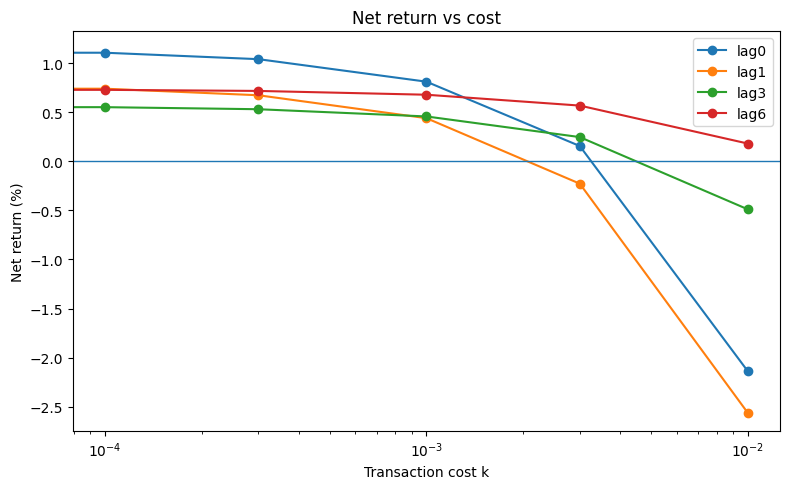

In [ ]:
def plot_matched_net_return_vs_k(matched_results):
    dfp = matched_results.reset_index().copy()

    plt.figure(figsize=(8, 5))
    for label in ['lag0','lag1', 'lag3', 'lag6']:
        sub = dfp[dfp['label'] == label].sort_values('k')
        if len(sub) > 0:
            plt.plot(sub['k'], sub['net_ann'] * 100, marker='o', label=label)

    plt.xscale('log')
    plt.xlabel('Transaction cost k')
    plt.ylabel('Net return (%)')
    plt.title('Net return vs cost')
    plt.axhline(0, linewidth=1)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_matched_net_return_vs_k(matched_results)

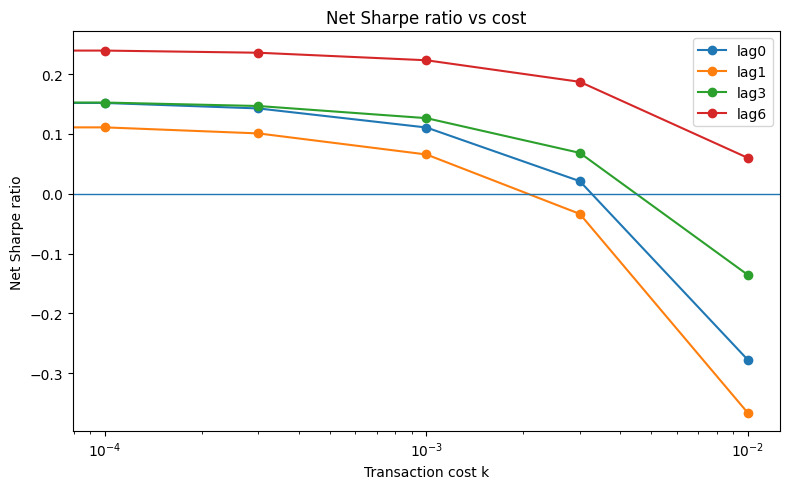

In [ ]:
def plot_matched_net_sharpe_vs_k(matched_results):
    dfp = matched_results.reset_index().copy()

    plt.figure(figsize=(8, 5))
    for label in ['lag0','lag1', 'lag3', 'lag6']:
        sub = dfp[dfp['label'] == label].sort_values('k')
        if len(sub) > 0:
            plt.plot(sub['k'], sub['net_sr'], marker='o', label=label)

    plt.xscale('log')
    plt.xlabel('Transaction cost k')
    plt.ylabel('Net Sharpe ratio')
    plt.title('Net Sharpe ratio vs cost')
    plt.axhline(0, linewidth=1)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_matched_net_sharpe_vs_k(matched_results)

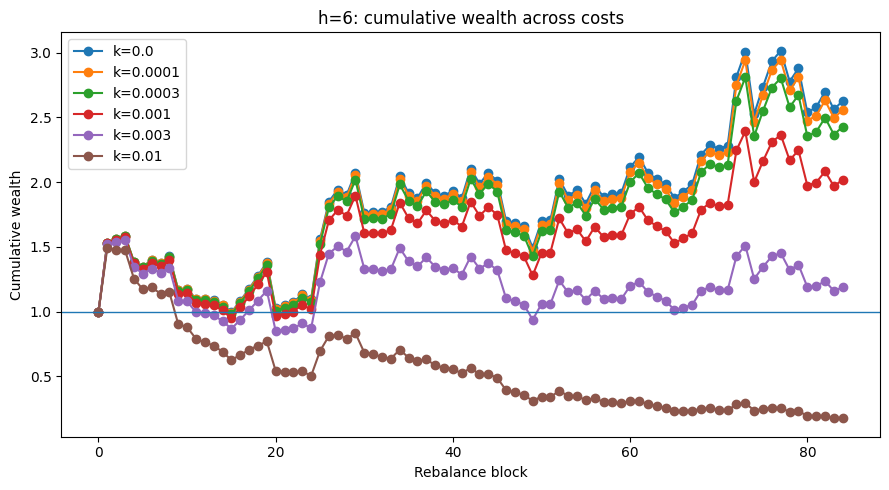

In [ ]:
def plot_one_matched_case_across_costs(df, signal_col, hold, k_values,
                                       date_col='yyyymm',
                                       id_col='FACTSET_ENTITY_ID',
                                       ret_col='mthret'):
    label = matched_label(signal_col)

    plt.figure(figsize=(9, 5))
    for k in k_values:
        wealth_df, _ = compute_wealth_path_signal(
            df,
            signal_col=signal_col,
            hold=hold,
            k=k,
            date_col=date_col,
            id_col=id_col,
            ret_col=ret_col
        )
        plt.plot(range(len(wealth_df)), wealth_df['wealth'], marker='o', label=f'k={k}')

    plt.xlabel('Rebalance block')
    plt.ylabel('Cumulative wealth')
    plt.title(f'h=6: cumulative wealth across costs')
    plt.axhline(1.0, linewidth=1)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_one_matched_case_across_costs(
    same_month_df,
    signal_col='pred_lag3',
    hold=3,
    k_values=[0.0, 1e-4, 3e-4, 1e-3, 3e-3, 1e-2],
    date_col='yyyymm',
    id_col='FACTSET_ENTITY_ID',
    ret_col='mthret'
)